## Calculations

### Imports

In [2]:
import openmc
import openmc.deplete
import numpy as np
import matplotlib.pyplot as plt
import h5py

h5_path = "../openmc_runs/homogen_model/runs/run_NO_UCO_37_10y/depletion_results.h5"
results = openmc.deplete.Results(h5_path)
chain = openmc.deplete.Chain.from_xml("../openmc_runs/homogen_model/input/chain_endfb71_pwr.xml")

step0 = results[0]
material_id = "10"

times_days = results.get_times(time_units='d')
times_years = results.get_times(time_units='a')

print("Number of steps:", len(times_days))
print("Final time [days]:", times_days[-1])
print("Final time [years]:", times_years[-1])

Number of steps: 21
Final time [days]: 3652.5
Final time [years]: 10.0


### Burnup conversion

In [3]:
with h5py.File(h5_path, "r") as f:
    time = np.array(f["time"][:], dtype=float)  # [t_start, t_end] in seconds

# Fjern eventuell final state hvis den finnes
if np.isclose(time[-1, 0], time[-1, 1]):
    time = time[:-1]

dt_s = time[:, 1] - time[:, 0]
t_end_s = time[:, 1]

# --- Reactor power used in depletion ---
power_W = 10e6   # må matche depletion-kjøringen din

# --- Energy released per fission ---
E_fission_J = 200.0e6 * 1.602176634e-19

# --- Cumulative fissions ---
fissions_per_step = power_W * dt_s / E_fission_J
cum_fissions = np.cumsum(fissions_per_step)

# --- Initial heavy metal inventory ---
heavy_metal_nuclides = ["U234", "U235", "U236", "U238"]

def get_atoms_array(results, material_id, nuc):
    _, atoms = results.get_atoms(material_id, nuc)
    return np.array(atoms, dtype=float)

N_HM0 = 0.0
for nuc in heavy_metal_nuclides:
    try:
        N_HM0 += get_atoms_array(results, material_id, nuc)[0]
    except Exception as e:
        print(f"{nuc} not found: {e}")

# --- FIMA burnup array ---
FIMA_array = 100.0 * cum_fissions / N_HM0

print(f"Final FIMA burnup: {FIMA_array[-1]:.2f}%")

Final FIMA burnup: 18.03%


In [4]:
def find_nearest_fima_step(target_fima, fima_array):
    return int(np.argmin(np.abs(fima_array - target_fima)))

# Test på noen av BU-verdiene fra RF-tabellene dine
test_targets = [7.3, 9.3, 10.0, 11.68, 12.0, 13.0, 16.0, 17.0, 18.64, 19.0]

for target in test_targets:
    step = find_nearest_fima_step(target, FIMA_array)
    matched = FIMA_array[step]
    print(f"Target FIMA {target:>5.2f}% -> step {step:>2d}, matched FIMA {matched:>6.2f}%")

Target FIMA  7.30% -> step 13, matched FIMA   7.51%
Target FIMA  9.30% -> step 14, matched FIMA   9.26%
Target FIMA 10.00% -> step 14, matched FIMA   9.26%
Target FIMA 11.68% -> step 15, matched FIMA  11.02%
Target FIMA 12.00% -> step 16, matched FIMA  12.77%
Target FIMA 13.00% -> step 16, matched FIMA  12.77%
Target FIMA 16.00% -> step 18, matched FIMA  16.28%
Target FIMA 17.00% -> step 18, matched FIMA  16.28%
Target FIMA 18.64% -> step 19, matched FIMA  18.03%
Target FIMA 19.00% -> step 19, matched FIMA  18.03%


### Activity conversion

In [5]:
nuclide_map = {n.name: n for n in chain.nuclides}

def decay_constant_s_inv(nuc):
    n = nuclide_map.get(nuc)
    if n is None:
        raise KeyError(f"Nuclide '{nuc}' not found in chain file.")
    hl = getattr(n, "half_life", None)
    if hl is None or hl == 0.0:
        return 0.0
    return np.log(2.0) / hl

def get_activity_array(results, material_id, nuc):
    _, atoms = results.get_atoms(material_id, nuc)
    atoms = np.array(atoms, dtype=float)
    lam = decay_constant_s_inv(nuc)
    return lam * atoms

def get_activity_at_fima(results, material_id, nuc, target_fima, fima_array):
    step = int(np.argmin(np.abs(fima_array - target_fima)))
    A = get_activity_array(results, material_id, nuc)
    return A[step], step, fima_array[step]

### AGR data

In [6]:
MC = {
    "Ag110m": {
        "min": {"value": 2.2e-4, "BU": 11.43, "TAVA": 1070},
        "max_intact": {"value": 1.7e-1, "BU": 15.25, "TAVA": 1111},
        "max_all": {"value": 1.7e-1, "BU": 15.25, "TAVA": 1111},
    },
    "Ce144": {
        "min": {"value": 6.6e-7, "BU": 19.38, "TAVA": 1072},
        "max_intact": {"value": 6.9e-4, "BU": 15.25, "TAVA": 1111},
        "max_all": {"value": 1.6e-3, "BU": 17.37, "TAVA": 1057},
    },
    "Cs134": {
        "min": {"value": 4.0e-7, "BU": 19.38, "TAVA": 1072},
        "max_intact": {"value": 2.1e-5, "BU": 15.25, "TAVA": 1111},
        "max_all": {"value": 5.7e-4, "BU": 10.80, "TAVA": 1261},
    },
    "Eu154": {
        "min": {"value": 2.4e-4, "BU": 19.38, "TAVA": 1072},
        "max_intact": {"value": 1.5e-2, "BU": 15.25, "TAVA": 1111},
        "max_all": {"value": 1.1e-1, "BU": 12.47, "TAVA": 1287},
    },
    "Sr90": {
        "min": {"value": 1.5e-6, "BU": 19.07, "TAVA": 1051},
        "max_intact": {"value": 2.6e-3, "BU": 16.14, "TAVA": 1092},
        "max_all": {"value": 8.2e-2, "BU": 12.47, "TAVA": 1287},
    }
}

RF_NO = {
    "Ag110m": {
        "min": {"value": 1.2e-2, "BU": 18.64, "TAVA": 1028},
        "max": {"value": 7.0e-1, "BU": 11.68, "TAVA": 1101},
    },
    "Ce144": {
        "min": {"value": 1.3e-6, "BU": 9.30, "TAVA": 1074},
        "max": {"value": 9.7e-6, "BU": 13.36, "TAVA": 1087},
    },
    "Cs134": {
        "min": {"value": 1.2e-5, "BU": 16.50, "TAVA": 1023},
        "max": {"value": 8.7e-5, "BU": 12.17, "TAVA": 1252},
    },
    "Eu154": {
        "min": {"value": 2.7e-5, "BU": 11.68, "TAVA": 1101},
        "max": {"value": 3.7e-2, "BU": 12.17, "TAVA": 1252},
    },
    "Sr90": {
        "min": {"value": 8.4e-7, "BU": 17.84, "TAVA": 1002},
        "max": {"value": 1.2e-2, "BU": 12.17, "TAVA": 1252},
    }
}

RF_DBA = {
    "Kr85": {
        "min": {"value": 7.0e-7, "BU": 13.0, "TAVA": 1296},
        "max_intact": {"value": 7.7e-6, "BU": 12.0, "TAVA": 1141},
        "max_all": {"value": 7.7e-6, "BU": 12.0, "TAVA": 1141},
    },
    "Sr90": {
        "min": {"value": 1.1e-5, "BU": 13.0, "TAVA": 1041},
        "max_intact": {"value": 8.6e-2, "BU": 13.0, "TAVA": 1296},
        "max_all": {"value": 8.6e-2, "BU": 13.0, "TAVA": 1296},
    },
    "Ag110m": {
        "min": {"value": 2.8e-3, "BU": 10.0, "TAVA": 1129},
        "max_intact": {"value": 3.4e-1, "BU": 19.0, "TAVA": 1094},
        "max_all": {"value": 3.4e-1, "BU": 19.0, "TAVA": 1094},
    },
    "Cs134": {
        "min": {"value": 2.5e-7, "BU": 13.0, "TAVA": 1287},
        "max_intact": {"value": 7.7e-6, "BU": 10.0, "TAVA": 1129},
        "max_all": {"value": 2.2e-4, "BU": 17.0, "TAVA": 1020},
    },
    "Eu154": {
        "min": {"value": 1.1e-4, "BU": 10.0, "TAVA": 1129},
        "max_intact": {"value": 8.8e-2, "BU": 13.0, "TAVA": 1296},
        "max_all": {"value": 8.8e-2, "BU": 13.0, "TAVA": 1296},
    }
}

RF_BDBA = {
    "Kr85": {
        "min": {"value": 7.0e-7, "BU": 12.0, "TAVA": 1071},
        "max_intact": {"value": 5.0e-6, "BU": 7.3, "TAVA": 987},
        "max_all": {"value": 4.7e-4, "BU": 16.0, "TAVA": 1057},
    },
    "Sr90": {
        "min": {"value": 5.4e-5, "BU": 7.3, "TAVA": 987},
        "max_intact": {"value": 9.7e-4, "BU": 19.0, "TAVA": 1059},
        "max_all": {"value": 9.9e-2, "BU": 13.0, "TAVA": 1296},
    },
    "Ag110m": {
        "min": {"value": 9.5e-3, "BU": 10.0, "TAVA": 1129},
        "max_intact": {"value": 1.7e-1, "BU": 19.0, "TAVA": 1059},
        "max_all": {"value": 2.3e-1, "BU": 19.0, "TAVA": 1057},
    },
    "Cs134": {
        "min": {"value": 7.3e-7, "BU": 19.0, "TAVA": 1059},
        "max_intact": {"value": 2.0e-5, "BU": 7.3, "TAVA": 987},
        "max_all": {"value": 1.6e-3, "BU": 19.0, "TAVA": 1053},
    },
    "Eu154": {
        "min": {"value": 9.5e-4, "BU": 7.3, "TAVA": 987},
        "max_intact": {"value": 2.9e-3, "BU": 19.0, "TAVA": 1059},
        "max_all": {"value": 1.4e-1, "BU": 13.0, "TAVA": 1296},
    }
}

nuclide_names = {
    "Ag110m": "Ag110_m1",
    "Ce144": "Ce144",
    "Cs134": "Cs134",
    "Eu154": "Eu154",
    "Sr90": "Sr90",
    "Kr85": "Kr85",
}

# --- Isotope groups used throughout the analysis ---

# Isotopes with complete NO + DBA + BDBA chains
isotopes_full = sorted(
    set(RF_NO.keys()) &
    set(RF_DBA.keys()) &
    set(RF_BDBA.keys())
)

# Isotopes with NO / pre-existing primary-system data
isotopes_no = sorted(RF_NO.keys())

# Isotopes with DBA/BDBA incremental data
isotopes_incremental = sorted(
    set(RF_DBA.keys()) |
    set(RF_BDBA.keys())
)

# Optional fixed plotting order
isotope_order_full = ["Ag110m", "Cs134", "Eu154", "Sr90"]
isotope_order_partial = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]

isotopes_full = [iso for iso in isotope_order_full if iso in isotopes_full]
isotopes_no = [iso for iso in isotope_order_partial if iso in isotopes_no]
isotopes_incremental = [iso for iso in isotope_order_partial if iso in isotopes_incremental]

print("isotopes_full:", isotopes_full)
print("isotopes_no:", isotopes_no)
print("isotopes_incremental:", isotopes_incremental)


isotopes_full: ['Ag110m', 'Cs134', 'Eu154', 'Sr90']
isotopes_no: ['Ag110m', 'Ce144', 'Cs134', 'Eu154', 'Sr90']
isotopes_incremental: ['Ag110m', 'Cs134', 'Eu154', 'Sr90', 'Kr85']


### Prompt retention factors

In [7]:
# --- Prompt lift-off fractions (measured COMEDIE values) ---
# SR = 1.7 -> minimum
# SR = 2.8 -> maximum
# Kr-85 treated as fully mobilized during prompt phase

LIFTOFF = {
    "Ag110m": {"min": 0.019, "max": 0.043},
    "Cs134": {"min": 0.020, "max": 0.028},
    "Sr90":  {"min": 0.36,  "max": 0.56},
    "Eu154": {"min": 0.36,  "max": 0.56},
    "Kr85":  {"min": 1.0,   "max": 1.0},
}

# --- Reactor building attenuation factors during prompt phase ---
# AF = 2 for condensables, AF = 1 for noble gases
AF_RB_prompt = {
    "Ag110m": {"min": 2.0, "max": 2.0},
    "Cs134":  {"min": 2.0, "max": 2.0},
    "Sr90":   {"min": 2.0, "max": 2.0},
    "Eu154":  {"min": 2.0, "max": 2.0},
    "Kr85":   {"min": 1.0, "max": 1.0},
}

### Delayed retention factors

In [8]:
# --- Helium Pressure Boundary attenuation factors (delayed phase) ---
# 50% values -> minimum release
# 95% values -> maximum release

AF_HPB_delayed = {
    "Kr85":   {"min": 5.0,  "max": 2.0},
    "Sr90":   {"min": 10.0, "max": 3.0},
    "Ag110m": {"min": 10.0, "max": 3.0},
    "Cs134":  {"min": 10.0, "max": 3.0},
    "Eu154":  {"min": 10.0, "max": 3.0},
}

# --- Reactor Building attenuation factors (delayed phase) ---
# 50% values -> minimum release
# 95% values -> maximum release

AF_RB_delayed = {
    "Kr85":   {"min": 1.0,  "max": 1.0},
    "Sr90":   {"min": 10.0, "max": 2.0},
    "Ag110m": {"min": 10.0, "max": 2.0},
    "Cs134":  {"min": 10.0, "max": 2.0},
    "Eu154":  {"min": 10.0, "max": 2.0},
}

### Inventories

In [9]:
fuel_inventory_RF_NO = {}
fuel_inventory_RF_DBA = {}
fuel_inventory_RF_BDBA = {}

for iso in RF_NO:
    nuc = nuclide_names[iso]  # OpenMC navn
    
    fuel_inventory_RF_NO[iso] = {}
    
    for case in ["min", "max"]:
        target_BU = RF_NO[iso][case]["BU"]
        
        A, step, matched_fima = get_activity_at_fima(
            results, material_id, nuc, target_BU, FIMA_array
        )
        
        fuel_inventory_RF_NO[iso][case] = {
            "activity": A,
            "step": step,
            "FIMA": matched_fima,
            "BU_target": target_BU
        }

for iso in RF_DBA:
    nuc = nuclide_names[iso]  # OpenMC-navn

    fuel_inventory_RF_DBA[iso] = {}

    for case in ["min", "max_intact", "max_all"]:
        target_BU = RF_DBA[iso][case]["BU"]

        A, step, matched_fima = get_activity_at_fima(
            results, material_id, nuc, target_BU, FIMA_array
        )

        fuel_inventory_RF_DBA[iso][case] = {
            "activity": A,
            "step": step,
            "FIMA": matched_fima,
            "BU_target": target_BU
        }

for iso in RF_BDBA:
    nuc = nuclide_names[iso]

    fuel_inventory_RF_BDBA[iso] = {}

    for case in ["min", "max_intact", "max_all"]:
        target_BU = RF_BDBA[iso][case]["BU"]

        A, step, matched_fima = get_activity_at_fima(
            results, material_id, nuc, target_BU, FIMA_array
        )

        fuel_inventory_RF_BDBA[iso][case] = {
            "activity": A,
            "step": step,
            "FIMA": matched_fima,
            "BU_target": target_BU
        }

In [10]:
for iso in fuel_inventory_RF_BDBA:
    print(f"\n{iso}:")
    for case in fuel_inventory_RF_BDBA[iso]:
        data = fuel_inventory_RF_BDBA[iso][case]
        print(
            f"  {case}: BU_target={data['BU_target']}, "
            f"matched={data['FIMA']:.2f}, "
            f"A={data['activity']:.2e}"
        )


Kr85:
  min: BU_target=12.0, matched=12.77, A=2.68e+14
  max_intact: BU_target=7.3, matched=7.51, A=1.63e+14
  max_all: BU_target=16.0, matched=16.28, A=3.20e+14

Sr90:
  min: BU_target=7.3, matched=7.51, A=1.25e+15
  max_intact: BU_target=19.0, matched=18.03, A=2.89e+15
  max_all: BU_target=13.0, matched=12.77, A=2.16e+15

Ag110m:
  min: BU_target=10.0, matched=9.26, A=9.34e+12
  max_intact: BU_target=19.0, matched=18.03, A=5.07e+13
  max_all: BU_target=19.0, matched=18.03, A=5.07e+13

Cs134:
  min: BU_target=19.0, matched=18.03, A=4.24e+15
  max_intact: BU_target=7.3, matched=7.51, A=7.29e+14
  max_all: BU_target=19.0, matched=18.03, A=4.24e+15

Eu154:
  min: BU_target=7.3, matched=7.51, A=2.58e+13
  max_intact: BU_target=19.0, matched=18.03, A=1.76e+14
  max_all: BU_target=13.0, matched=12.77, A=9.40e+13


### Activity in primary system

In [11]:
A_primary_NO = {}       # Pre-existing activity in primary system
A_primary_DBA = {}      # Incremental activity in primary system due to DBA
A_primary_BDBA = {}     # Incremental activity in primary system due to BDBA

# --- NO baseline ---
for iso in RF_NO:
    A_primary_NO[iso] = {
        "min": fuel_inventory_RF_NO[iso]["min"]["activity"] * RF_NO[iso]["min"]["value"],
        "max": fuel_inventory_RF_NO[iso]["max"]["activity"] * RF_NO[iso]["max"]["value"]
    }

# --- DBA incremental ---
for iso in RF_DBA:
    A_primary_DBA[iso] = {
        "min": fuel_inventory_RF_DBA[iso]["min"]["activity"] * RF_DBA[iso]["min"]["value"],
        "max_intact": fuel_inventory_RF_DBA[iso]["max_intact"]["activity"] * RF_DBA[iso]["max_intact"]["value"],
        "max_all": fuel_inventory_RF_DBA[iso]["max_all"]["activity"] * RF_DBA[iso]["max_all"]["value"]
    }

# --- BDBA incremental ---
for iso in RF_BDBA:
    A_primary_BDBA[iso] = {
        "min": fuel_inventory_RF_BDBA[iso]["min"]["activity"] * RF_BDBA[iso]["min"]["value"],
        "max_intact": fuel_inventory_RF_BDBA[iso]["max_intact"]["activity"] * RF_BDBA[iso]["max_intact"]["value"],
        "max_all": fuel_inventory_RF_BDBA[iso]["max_all"]["activity"] * RF_BDBA[iso]["max_all"]["value"]
    }

# --- Total primary activity envelopes ---
# Only for isotopes with complete baseline + incremental data
A_primary_DBA_total = {}
A_primary_BDBA_total = {}

for iso in isotopes_full:
    A_primary_DBA_total[iso] = {
        "min": A_primary_NO[iso]["min"] + A_primary_DBA[iso]["min"],
        "max_intact": A_primary_NO[iso]["max"] + A_primary_DBA[iso]["max_intact"],
        "max_all": A_primary_NO[iso]["max"] + A_primary_DBA[iso]["max_all"],
    }

    A_primary_BDBA_total[iso] = {
        "min": A_primary_NO[iso]["min"] + A_primary_BDBA[iso]["min"],
        "max_intact": A_primary_NO[iso]["max"] + A_primary_BDBA[iso]["max_intact"],
        "max_all": A_primary_NO[iso]["max"] + A_primary_BDBA[iso]["max_all"],
    }

In [12]:
for iso in A_primary_BDBA:
    print(
        f"{iso}: "
        f"min={A_primary_BDBA[iso]['min']:.2e} Bq, "
        f"max_intact={A_primary_BDBA[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_primary_BDBA[iso]['max_all']:.2e} Bq"
    )

Kr85: min=1.88e+08 Bq, max_intact=8.17e+08 Bq, max_all=1.50e+11 Bq
Sr90: min=6.73e+10 Bq, max_intact=2.80e+12 Bq, max_all=2.14e+14 Bq
Ag110m: min=8.87e+10 Bq, max_intact=8.62e+12 Bq, max_all=1.17e+13 Bq
Cs134: min=3.09e+09 Bq, max_intact=1.46e+10 Bq, max_all=6.78e+12 Bq
Eu154: min=2.45e+10 Bq, max_intact=5.10e+11 Bq, max_all=1.32e+13 Bq


### Activity in reactor building

In [13]:
A_building_prompt = {}             # From pre-existing primary system activity and prompt lift-off fractions
A_building_DBA_incremental = {}    # From incremental primary system activity due to DBA and delayed HPB attenuation
A_building_BDBA_incremental = {}   # From incremental primary system activity due to BDBA and delayed HPB attenuation

A_building_DBA_total = {}          # Prompt + DBA incremental
A_building_BDBA_total = {}         # Prompt + BDBA incremental

# --- Prompt release to reactor building ---
# Only isotopes with NO baseline and lift-off data
prompt_isotopes = sorted(set(isotopes_no) & set(A_primary_NO.keys()) & set(LIFTOFF.keys()))

for iso in prompt_isotopes:
    A_building_prompt[iso] = {
        "min": A_primary_NO[iso]["min"] * LIFTOFF[iso]["min"],
        "max": A_primary_NO[iso]["max"] * LIFTOFF[iso]["max"]
    }

# --- Delayed DBA incremental release to reactor building ---
# Only isotopes with DBA incremental data and delayed HPB attenuation
dba_incremental_isotopes = sorted(set(isotopes_incremental) & set(A_primary_DBA.keys()) & set(AF_HPB_delayed.keys()))

for iso in dba_incremental_isotopes:
    A_building_DBA_incremental[iso] = {
        "min": A_primary_DBA[iso]["min"] / AF_HPB_delayed[iso]["min"],
        "max_intact": A_primary_DBA[iso]["max_intact"] / AF_HPB_delayed[iso]["max"],
        "max_all": A_primary_DBA[iso]["max_all"] / AF_HPB_delayed[iso]["max"],
    }

# --- Delayed BDBA incremental release to reactor building ---
# Only isotopes with BDBA incremental data and delayed HPB attenuation
bdba_incremental_isotopes = sorted(set(isotopes_incremental) & set(A_primary_BDBA.keys()) & set(AF_HPB_delayed.keys()))

for iso in bdba_incremental_isotopes:
    A_building_BDBA_incremental[iso] = {
        "min": A_primary_BDBA[iso]["min"] / AF_HPB_delayed[iso]["min"],
        "max_intact": A_primary_BDBA[iso]["max_intact"] / AF_HPB_delayed[iso]["max"],
        "max_all": A_primary_BDBA[iso]["max_all"] / AF_HPB_delayed[iso]["max"],
    }

# --- Total release to reactor building ---
# Only isotopes with complete baseline + incremental data
for iso in isotopes_full:
    A_building_DBA_total[iso] = {
        "min": A_building_prompt[iso]["min"] + A_building_DBA_incremental[iso]["min"],
        "max_intact": A_building_prompt[iso]["max"] + A_building_DBA_incremental[iso]["max_intact"],
        "max_all": A_building_prompt[iso]["max"] + A_building_DBA_incremental[iso]["max_all"],
    }

    A_building_BDBA_total[iso] = {
        "min": A_building_prompt[iso]["min"] + A_building_BDBA_incremental[iso]["min"],
        "max_intact": A_building_prompt[iso]["max"] + A_building_BDBA_incremental[iso]["max_intact"],
        "max_all": A_building_prompt[iso]["max"] + A_building_BDBA_incremental[iso]["max_all"],
    }

In [14]:
print("Prompt:")
for iso in A_building_prompt:
    print(
        f"{iso}: "
        f"min={A_building_prompt[iso]['min']:.2e} Bq, "
        f"max={A_building_prompt[iso]['max']:.2e} Bq"
    )

print("\nDelayed DBA contribution:")
for iso in A_building_DBA_incremental:
    print(
        f"{iso}: "
        f"min={A_building_DBA_incremental[iso]['min']:.2e} Bq, "
        f"max_intact={A_building_DBA_incremental[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_building_DBA_incremental[iso]['max_all']:.2e} Bq"
    )

print("\nDelayed BDBA contribution:")
for iso in A_building_BDBA_incremental:
    print(
        f"{iso}: "
        f"min={A_building_BDBA_incremental[iso]['min']:.2e} Bq, "
        f"max_intact={A_building_BDBA_incremental[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_building_BDBA_incremental[iso]['max_all']:.2e} Bq"
    )

print("\nDBA total to reactor building:")
for iso in A_building_DBA_total:
    print(
        f"{iso}: "
        f"min={A_building_DBA_total[iso]['min']:.2e} Bq, "
        f"max_intact={A_building_DBA_total[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_building_DBA_total[iso]['max_all']:.2e} Bq"
    )

print("\nBDBA total to reactor building:")
for iso in A_building_BDBA_total:
    print(
        f"{iso}: "
        f"min={A_building_BDBA_total[iso]['min']:.2e} Bq, "
        f"max_intact={A_building_BDBA_total[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_building_BDBA_total[iso]['max_all']:.2e} Bq"
    )

Prompt:
Ag110m: min=1.16e+10 Bq, max=4.35e+11 Bq
Cs134: min=8.42e+08 Bq, max=5.42e+09 Bq
Eu154: min=6.58e+08 Bq, max=1.95e+12 Bq
Sr90: min=8.73e+08 Bq, max=1.45e+13 Bq

Delayed DBA contribution:
Ag110m: min=2.62e+09 Bq, max_intact=5.75e+12 Bq, max_all=5.75e+12 Bq
Cs134: min=5.56e+07 Bq, max_intact=2.98e+09 Bq, max_all=2.57e+11 Bq
Eu154: min=4.88e+08 Bq, max_intact=2.76e+12 Bq, max_all=2.76e+12 Bq
Kr85: min=3.76e+07 Bq, max_intact=1.03e+09 Bq, max_all=1.03e+09 Bq
Sr90: min=2.37e+09 Bq, max_intact=6.18e+13 Bq, max_all=6.18e+13 Bq

Delayed BDBA contribution:
Ag110m: min=8.87e+09 Bq, max_intact=2.87e+12 Bq, max_all=3.89e+12 Bq
Cs134: min=3.09e+08 Bq, max_intact=4.86e+09 Bq, max_all=2.26e+12 Bq
Eu154: min=2.45e+09 Bq, max_intact=1.70e+11 Bq, max_all=4.39e+12 Bq
Kr85: min=3.76e+07 Bq, max_intact=4.08e+08 Bq, max_all=7.51e+10 Bq
Sr90: min=6.73e+09 Bq, max_intact=9.33e+11 Bq, max_all=7.12e+13 Bq

DBA total to reactor building:
Ag110m: min=1.42e+10 Bq, max_intact=6.18e+12 Bq, max_all=6.18e+12 B

### Activity in enviornment

In [15]:
A_environment_prompt = {}            # From prompt release to reactor building and prompt RB attenuation
A_environment_DBA_incremental = {}   # From delayed DBA release to reactor building and delayed RB attenuation
A_environment_BDBA_incremental = {}  # From delayed BDBA release to reactor building and delayed RB attenuation

A_environment_DBA_total = {}         # Prompt + DBA incremental
A_environment_BDBA_total = {}        # Prompt + BDBA incremental

# --- Prompt release to environment ---
# Only isotopes with prompt release to reactor building and prompt RB attenuation data
prompt_env_isotopes = sorted(set(isotopes_no) & set(A_building_prompt.keys()) & set(AF_RB_prompt.keys()))

for iso in prompt_env_isotopes:
    A_environment_prompt[iso] = {
        "min": A_building_prompt[iso]["min"] / AF_RB_prompt[iso]["min"],
        "max": A_building_prompt[iso]["max"] / AF_RB_prompt[iso]["max"]
    }

# --- Delayed DBA incremental release to environment ---
# Only isotopes with delayed DBA building release and delayed RB attenuation data
dba_incremental_env_isotopes = sorted(set(isotopes_incremental) & set(A_building_DBA_incremental.keys()) & set(AF_RB_delayed.keys()))

for iso in dba_incremental_env_isotopes:
    A_environment_DBA_incremental[iso] = {
        "min": A_building_DBA_incremental[iso]["min"] / AF_RB_delayed[iso]["min"],
        "max_intact": A_building_DBA_incremental[iso]["max_intact"] / AF_RB_delayed[iso]["max"],
        "max_all": A_building_DBA_incremental[iso]["max_all"] / AF_RB_delayed[iso]["max"],
    }

# --- Delayed BDBA incremental release to environment ---
# Only isotopes with delayed BDBA building release and delayed RB attenuation data
bdba_incremental_env_isotopes = sorted(set(isotopes_incremental) & set(A_building_BDBA_incremental.keys()) & set(AF_RB_delayed.keys()))

for iso in bdba_incremental_env_isotopes:
    A_environment_BDBA_incremental[iso] = {
        "min": A_building_BDBA_incremental[iso]["min"] / AF_RB_delayed[iso]["min"],
        "max_intact": A_building_BDBA_incremental[iso]["max_intact"] / AF_RB_delayed[iso]["max"],
        "max_all": A_building_BDBA_incremental[iso]["max_all"] / AF_RB_delayed[iso]["max"],
    }

# --- Total release to environment ---
# Only isotopes with complete baseline + incremental data
for iso in isotopes_full:
    A_environment_DBA_total[iso] = {
        "min": A_environment_prompt[iso]["min"] + A_environment_DBA_incremental[iso]["min"],
        "max_intact": A_environment_prompt[iso]["max"] + A_environment_DBA_incremental[iso]["max_intact"],
        "max_all": A_environment_prompt[iso]["max"] + A_environment_DBA_incremental[iso]["max_all"],
    }

    A_environment_BDBA_total[iso] = {
        "min": A_environment_prompt[iso]["min"] + A_environment_BDBA_incremental[iso]["min"],
        "max_intact": A_environment_prompt[iso]["max"] + A_environment_BDBA_incremental[iso]["max_intact"],
        "max_all": A_environment_prompt[iso]["max"] + A_environment_BDBA_incremental[iso]["max_all"],
    }

In [16]:
print("Prompt to environment:")
for iso in A_environment_prompt:
    print(
        f"{iso}: "
        f"min={A_environment_prompt[iso]['min']:.2e} Bq, "
        f"max={A_environment_prompt[iso]['max']:.2e} Bq"
    )

print("\nDelayed DBA contribution to environment:")
for iso in A_environment_DBA_incremental:
    print(
        f"{iso}: "
        f"min={A_environment_DBA_incremental[iso]['min']:.2e} Bq, "
        f"max_intact={A_environment_DBA_incremental[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_environment_DBA_incremental[iso]['max_all']:.2e} Bq"
    )

print("\nDelayed BDBA contribution to environment:")
for iso in A_environment_BDBA_incremental:
    print(
        f"{iso}: "
        f"min={A_environment_BDBA_incremental[iso]['min']:.2e} Bq, "
        f"max_intact={A_environment_BDBA_incremental[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_environment_BDBA_incremental[iso]['max_all']:.2e} Bq"
    )

print("\nDBA total to environment:")
for iso in A_environment_DBA_total:
    print(
        f"{iso}: "
        f"min={A_environment_DBA_total[iso]['min']:.2e} Bq, "
        f"max_intact={A_environment_DBA_total[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_environment_DBA_total[iso]['max_all']:.2e} Bq"
    )

print("\nBDBA total to environment:")
for iso in A_environment_BDBA_total:
    print(
        f"{iso}: "
        f"min={A_environment_BDBA_total[iso]['min']:.2e} Bq, "
        f"max_intact={A_environment_BDBA_total[iso]['max_intact']:.2e} Bq, "
        f"max_all={A_environment_BDBA_total[iso]['max_all']:.2e} Bq"
    )

Prompt to environment:
Ag110m: min=5.78e+09 Bq, max=2.18e+11 Bq
Cs134: min=4.21e+08 Bq, max=2.71e+09 Bq
Eu154: min=3.29e+08 Bq, max=9.74e+11 Bq
Sr90: min=4.36e+08 Bq, max=7.25e+12 Bq

Delayed DBA contribution to environment:
Ag110m: min=2.62e+08 Bq, max_intact=2.87e+12 Bq, max_all=2.87e+12 Bq
Cs134: min=5.56e+06 Bq, max_intact=1.49e+09 Bq, max_all=1.29e+11 Bq
Eu154: min=4.88e+07 Bq, max_intact=1.38e+12 Bq, max_all=1.38e+12 Bq
Kr85: min=3.76e+07 Bq, max_intact=1.03e+09 Bq, max_all=1.03e+09 Bq
Sr90: min=2.37e+08 Bq, max_intact=3.09e+13 Bq, max_all=3.09e+13 Bq

Delayed BDBA contribution to environment:
Ag110m: min=8.87e+08 Bq, max_intact=1.44e+12 Bq, max_all=1.94e+12 Bq
Cs134: min=3.09e+07 Bq, max_intact=2.43e+09 Bq, max_all=1.13e+12 Bq
Eu154: min=2.45e+08 Bq, max_intact=8.49e+10 Bq, max_all=2.19e+12 Bq
Kr85: min=3.76e+07 Bq, max_intact=4.08e+08 Bq, max_all=7.51e+10 Bq
Sr90: min=6.73e+08 Bq, max_intact=4.67e+11 Bq, max_all=3.56e+13 Bq

DBA total to environment:
Ag110m: min=6.04e+09 Bq, ma

## Plot

### matrix in-service accumulation

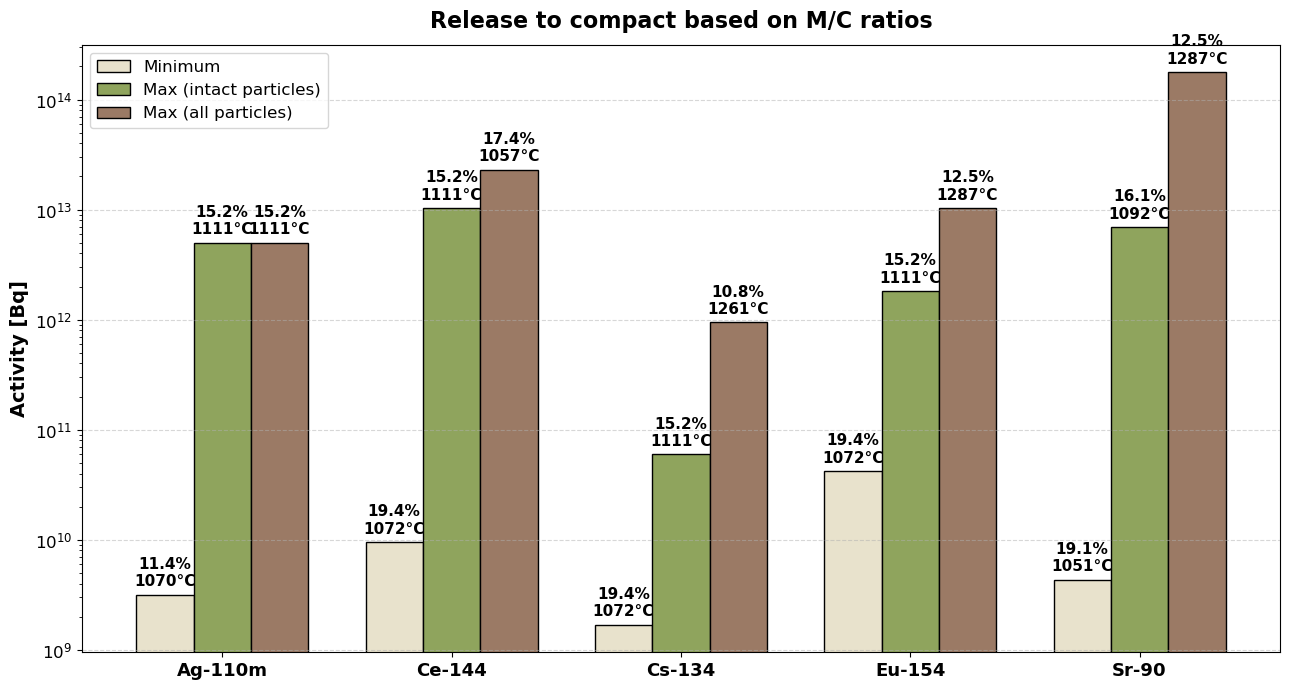

BU-matched M/C release values:
----------------------------------------------------------------------------------------------------

Ag-110m
         min: BU target =  11.43 %, matched BU =  11.02 %, inventory = 1.445e+13 Bq, M/C = 2.200e-04, compact = 3.180e+09 Bq
  max_intact: BU target =  15.25 %, matched BU =  14.52 %, inventory = 2.953e+13 Bq, M/C = 1.700e-01, compact = 5.019e+12 Bq
     max_all: BU target =  15.25 %, matched BU =  14.52 %, inventory = 2.953e+13 Bq, M/C = 1.700e-01, compact = 5.019e+12 Bq

Ce-144
         min: BU target =  19.38 %, matched BU =  18.03 %, inventory = 1.438e+16 Bq, M/C = 6.600e-07, compact = 9.494e+09 Bq
  max_intact: BU target =  15.25 %, matched BU =  14.52 %, inventory = 1.499e+16 Bq, M/C = 6.900e-04, compact = 1.034e+13 Bq
     max_all: BU target =  17.37 %, matched BU =  18.03 %, inventory = 1.438e+16 Bq, M/C = 1.600e-03, compact = 2.302e+13 Bq

Cs-134
         min: BU target =  19.38 %, matched BU =  18.03 %, inventory = 4.236e+15 Bq, M/C = 4.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 15 — Release to compact based on M/C ratios
# With inventories matched to BU values of each M/C case
# ============================================================

isotopes = list(MC.keys())

label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85",
}

labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Colors ---
try:
    color_min = jordBeige
except NameError:
    color_min = "#E8E2CC"

try:
    color_intact = jordOliven
except NameError:
    color_intact = "#8FA45D"

try:
    color_all = jordBrun
except NameError:
    color_all = "#9B7A65"

# ============================================================
# BU-matched fuel inventories for M/C cases
# ============================================================

fuel_inventory_MC_BU = {}

for iso in isotopes:
    nuc = nuclide_names[iso]
    fuel_inventory_MC_BU[iso] = {}

    for case in ["min", "max_intact", "max_all"]:
        target_BU = MC[iso][case]["BU"]

        A, step, matched_fima = get_activity_at_fima(
            results,
            material_id,
            nuc,
            target_BU,
            FIMA_array
        )

        fuel_inventory_MC_BU[iso][case] = {
            "activity": A,
            "step": step,
            "FIMA": matched_fima,
            "BU_target": target_BU,
        }

# ============================================================
# Release to compact = BU-matched inventory × M/C fraction
# ============================================================

A_compact_MC_BU = {}

for iso in isotopes:
    A_compact_MC_BU[iso] = {
        "min": (
            fuel_inventory_MC_BU[iso]["min"]["activity"]
            * MC[iso]["min"]["value"]
        ),
        "max_intact": (
            fuel_inventory_MC_BU[iso]["max_intact"]["activity"]
            * MC[iso]["max_intact"]["value"]
        ),
        "max_all": (
            fuel_inventory_MC_BU[iso]["max_all"]["activity"]
            * MC[iso]["max_all"]["value"]
        ),
    }

mc_min = [A_compact_MC_BU[iso]["min"] for iso in isotopes]
mc_intact = [A_compact_MC_BU[iso]["max_intact"] for iso in isotopes]
mc_all = [A_compact_MC_BU[iso]["max_all"] for iso in isotopes]

# ============================================================
# Plot
# ============================================================

x = np.arange(len(isotopes))
width = 0.25

plt.figure(figsize=(13, 7), facecolor="white")

bars_min = plt.bar(
    x - width,
    mc_min,
    width,
    color=color_min,
    edgecolor="black",
    label="Minimum",
)

bars_intact = plt.bar(
    x,
    mc_intact,
    width,
    color=color_intact,
    edgecolor="black",
    label="Max (intact particles)",
)

bars_all = plt.bar(
    x + width,
    mc_all,
    width,
    color=color_all,
    edgecolor="black",
    label="Max (all particles)",
)

# ============================================================
# Larger BU/TAVA annotations
# ============================================================

annotation_fontsize = 11

for bar, iso in zip(bars_min, isotopes):
    height = bar.get_height()
    BU = MC[iso]["min"]["BU"]
    TAVA = MC[iso]["min"]["TAVA"]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.12,
        f"{BU:.1f}%\n{TAVA:.0f}°C",
        ha="center",
        va="bottom",
        fontsize=annotation_fontsize,
        fontweight="bold",
    )

for bar, iso in zip(bars_intact, isotopes):
    height = bar.get_height()
    BU = MC[iso]["max_intact"]["BU"]
    TAVA = MC[iso]["max_intact"]["TAVA"]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.12,
        f"{BU:.1f}%\n{TAVA:.0f}°C",
        ha="center",
        va="bottom",
        fontsize=annotation_fontsize,
        fontweight="bold",
    )

for bar, iso in zip(bars_all, isotopes):
    height = bar.get_height()
    BU = MC[iso]["max_all"]["BU"]
    TAVA = MC[iso]["max_all"]["TAVA"]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.12,
        f"{BU:.1f}%\n{TAVA:.0f}°C",
        ha="center",
        va="bottom",
        fontsize=annotation_fontsize,
        fontweight="bold",
    )

# ============================================================
# Axes styling
# ============================================================

plt.xticks(x, labels, fontsize=13, fontweight="bold")
plt.yticks(fontsize=12)

plt.yscale("log")
plt.ylabel("Activity [Bq]", fontsize=14, fontweight="bold")

plt.title(
    "Release to compact based on M/C ratios",
    fontsize=16,
    fontweight="bold",
    pad=12,
)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================
# Diagnostic printout
# ============================================================

print("BU-matched M/C release values:")
print("-" * 100)

for iso in isotopes:
    print(f"\n{label_map.get(iso, iso)}")

    for case in ["min", "max_intact", "max_all"]:
        inv = fuel_inventory_MC_BU[iso][case]["activity"]
        mc = MC[iso][case]["value"]
        A = A_compact_MC_BU[iso][case]
        target_BU = fuel_inventory_MC_BU[iso][case]["BU_target"]
        matched_BU = fuel_inventory_MC_BU[iso][case]["FIMA"]

        print(
            f"  {case:>10}: "
            f"BU target = {target_BU:6.2f} %, "
            f"matched BU = {matched_BU:6.2f} %, "
            f"inventory = {inv:.3e} Bq, "
            f"M/C = {mc:.3e}, "
            f"compact = {A:.3e} Bq"
        )

### Primary system in-service accumulation

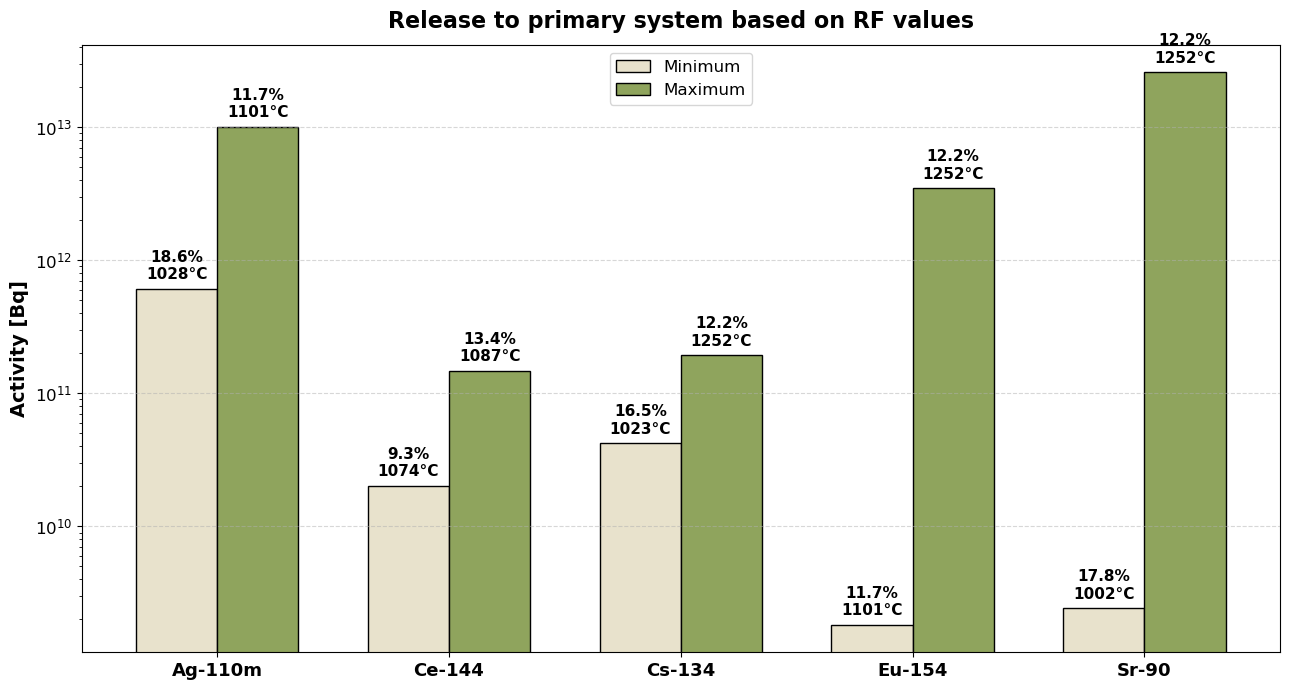

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 16 — Publication-quality formatting
# ============================================================

isotopes = list(RF_NO.keys())

label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85",
}

labels = [label_map.get(iso, iso) for iso in isotopes]

# Colors
color_min = "#E8E2CC"
color_max = "#8FA45D"

# ============================================================
# BU-matched inventories
# ============================================================

fuel_inventory_RF_NO_BU = {}

for iso in isotopes:
    nuc = nuclide_names[iso]
    fuel_inventory_RF_NO_BU[iso] = {}

    for case in ["min", "max"]:
        target_BU = RF_NO[iso][case]["BU"]

        A, step, matched_fima = get_activity_at_fima(
            results,
            material_id,
            nuc,
            target_BU,
            FIMA_array
        )

        fuel_inventory_RF_NO_BU[iso][case] = {
            "activity": A,
            "FIMA": matched_fima,
            "BU_target": target_BU,
        }

# ============================================================
# Compute releases
# ============================================================

A_primary_RF_NO_BU = {
    iso: {
        "min": fuel_inventory_RF_NO_BU[iso]["min"]["activity"] * RF_NO[iso]["min"]["value"],
        "max": fuel_inventory_RF_NO_BU[iso]["max"]["activity"] * RF_NO[iso]["max"]["value"],
    }
    for iso in isotopes
}

rf_min = [A_primary_RF_NO_BU[iso]["min"] for iso in isotopes]
rf_max = [A_primary_RF_NO_BU[iso]["max"] for iso in isotopes]

# ============================================================
# Plot
# ============================================================

x = np.arange(len(isotopes))
width = 0.35

plt.figure(figsize=(13, 7), facecolor="white")

bars_min = plt.bar(
    x - width / 2,
    rf_min,
    width,
    color=color_min,
    edgecolor="black",
    label="Minimum",
)

bars_max = plt.bar(
    x + width / 2,
    rf_max,
    width,
    color=color_max,
    edgecolor="black",
    label="Maximum",
)

# ============================================================
# LARGE annotations (key change)
# ============================================================

for bar, iso in zip(bars_min, isotopes):
    height = bar.get_height()
    BU = RF_NO[iso]["min"]["BU"]
    TAVA = RF_NO[iso]["min"]["TAVA"]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.12,
        f"{BU:.1f}%\n{TAVA:.0f}°C",
        ha="center",
        va="bottom",
        fontsize=11,          # ⬅️ increased
        fontweight="bold"
    )

for bar, iso in zip(bars_max, isotopes):
    height = bar.get_height()
    BU = RF_NO[iso]["max"]["BU"]
    TAVA = RF_NO[iso]["max"]["TAVA"]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.12,
        f"{BU:.1f}%\n{TAVA:.0f}°C",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# Axes styling (larger fonts)
# ============================================================

plt.xticks(x, labels, fontsize=13, fontweight="bold")   # ⬅️ isotopes larger
plt.yticks(fontsize=12)

plt.yscale("log")

plt.ylabel("Activity [Bq]", fontsize=14, fontweight="bold")
plt.title(
    "Release to primary system based on RF values",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Release to the primary system

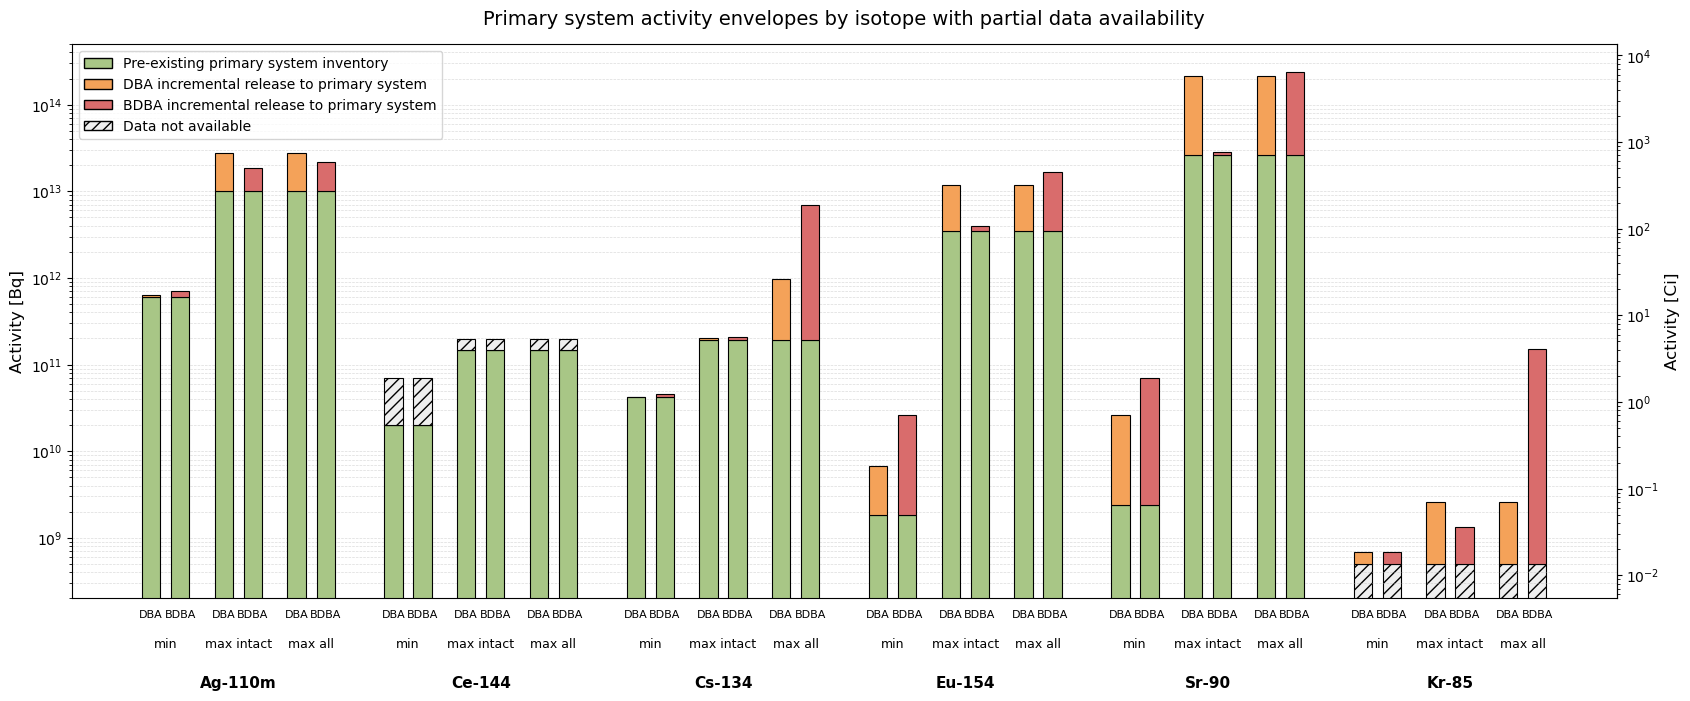

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Penere isotopnavn ---
label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}

# --- Isotoper ---
isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Hjelpefunksjon ---
def get_case_value(dct, iso, case, default=0.0):
    if iso in dct and case in dct[iso]:
        return dct[iso][case]
    return default

# --- Farger ---
color_NO = (168/255, 198/255, 134/255)   # lys grønn
color_DBA = (244/255, 162/255, 89/255)   # varm oransje
color_BDBA = (217/255, 108/255, 108/255) # myk rød
color_missing = "#efefef"

# --- Data ---
NO_min = np.array([get_case_value(A_primary_NO, iso, "min") for iso in isotopes])
NO_max = np.array([get_case_value(A_primary_NO, iso, "max") for iso in isotopes])

DBA_min = np.array([get_case_value(A_primary_DBA, iso, "min") for iso in isotopes])
DBA_max_intact = np.array([get_case_value(A_primary_DBA, iso, "max_intact") for iso in isotopes])
DBA_max_all = np.array([get_case_value(A_primary_DBA, iso, "max_all") for iso in isotopes])

BDBA_min = np.array([get_case_value(A_primary_BDBA, iso, "min") for iso in isotopes])
BDBA_max_intact = np.array([get_case_value(A_primary_BDBA, iso, "max_intact") for iso in isotopes])
BDBA_max_all = np.array([get_case_value(A_primary_BDBA, iso, "max_all") for iso in isotopes])

# --- X-posisjoner ---
x = np.arange(len(isotopes))

pair_offset = 0.3
within_pair = 0.12
width = 0.075

# Min-pair
pos_min_DBA = x - pair_offset - within_pair/2
pos_min_BDBA = x - pair_offset + within_pair/2

# Intact-pair
pos_intact_DBA = x - within_pair/2
pos_intact_BDBA = x + within_pair/2

# All-pair
pos_all_DBA = x + pair_offset - within_pair/2
pos_all_BDBA = x + pair_offset + within_pair/2

# --- Plotinnstillinger ---
ymin = 2e8
ymax = 5e14

KR_BASE = 5e8
CE_HATCH = 5e10

# --- Figur ---
fig, ax = plt.subplots(figsize=(17, 8), facecolor="white")
ax.set_facecolor("white")

def draw_one_bar(xpos, iso, base, increment):
    # Case 1: isotopen har baseline
    if iso in A_primary_NO:
        ax.bar(xpos, base, width, color=color_NO, edgecolor="black", linewidth=0.8, zorder=2)
        ax.bar(xpos, increment, width, bottom=base, color=current_increment_color,
               edgecolor="black", linewidth=0.8, zorder=3)
    # Case 2: isotopen mangler baseline, bruk hatch som basis
    else:
        ax.bar(xpos, KR_BASE, width, color=color_missing, edgecolor="black",
               hatch="///", linewidth=0.8, zorder=1)
        ax.bar(xpos, increment, width, bottom=KR_BASE, color=current_increment_color,
               edgecolor="black", linewidth=0.8, zorder=3)

def add_ce_missing_increment(xpos, iso, base, scenario):
    if iso != "Ce144":
        return
    if scenario == "DBA" and iso not in A_primary_DBA:
        ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
               edgecolor="black", hatch="///", linewidth=0.8, zorder=4)
    if scenario == "BDBA" and iso not in A_primary_BDBA:
        ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
               edgecolor="black", hatch="///", linewidth=0.8, zorder=4)

# =========================
# Minimum pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_min_DBA[i], iso, NO_min[i], DBA_min[i])
    add_ce_missing_increment(pos_min_DBA[i], iso, max(NO_min[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_min_BDBA[i], iso, NO_min[i], BDBA_min[i])
    add_ce_missing_increment(pos_min_BDBA[i], iso, max(NO_min[i], ymin), "BDBA")

# =========================
# Max intact pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_intact_DBA[i], iso, NO_max[i], DBA_max_intact[i])
    add_ce_missing_increment(pos_intact_DBA[i], iso, max(NO_max[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_intact_BDBA[i], iso, NO_max[i], BDBA_max_intact[i])
    add_ce_missing_increment(pos_intact_BDBA[i], iso, max(NO_max[i], ymin), "BDBA")

# =========================
# Max all pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_all_DBA[i], iso, NO_max[i], DBA_max_all[i])
    add_ce_missing_increment(pos_all_DBA[i], iso, max(NO_max[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_all_BDBA[i], iso, NO_max[i], BDBA_max_all[i])
    add_ce_missing_increment(pos_all_BDBA[i], iso, max(NO_max[i], ymin), "BDBA")

# --- Aksene ---
ax.set_xticks([])
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_ylabel("Activity [Bq]", fontsize=12)
ax.set_title("Primary system activity envelopes by isotope with partial data availability", fontsize=14, pad=14)

# --- Grid ---
ax.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.45)

# --- Legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_NO, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_DBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_BDBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_missing, ec="black", hatch="///"),
]
legend_labels = [
    "Pre-existing primary system inventory",
    "DBA incremental release to primary system",
    "BDBA incremental release to primary system",
    "Data not available"
]
ax.legend(handles, legend_labels, loc="upper left", frameon=True, fontsize=10)

# --- Scenarioetiketter nærmest stolpene ---
for i in range(len(x)):
    ax.text(pos_min_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_min_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

    ax.text(pos_intact_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_intact_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

    ax.text(pos_all_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_all_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

# --- Envelopeetiketter under scenarioetikettene ---
for i in range(len(x)):
    ax.text(x[i] - pair_offset, -0.07, "min", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)
    ax.text(x[i], -0.07, "max intact", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)
    ax.text(x[i] + pair_offset, -0.07, "max all", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)

# --- Isotopnavn helt nederst ---
for i, label in enumerate(labels):
    ax.text(x[i], -0.14, label, transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=11, fontweight="bold")
    
from matplotlib.ticker import LogFormatterSciNotation

CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

ax.set_yscale("log")
ax.set_ylabel("Activity [Bq]", fontsize=12)

secax = ax.secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax.set_ylabel("Activity [Ci]", fontsize=12)
secax.yaxis.set_major_formatter(LogFormatterSciNotation())

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

Primary system activity envelopes by isotope with partial data availability.
The figure presents six bars per isotope, grouped into three pairs corresponding to minimum (left), maximum with intact particles (center), and maximum with all particles (right). Within each pair, the left bar represents the DBA scenario and the right bar represents the BDBA scenario. Each bar is composed of a stacked representation of the pre-existing primary system inventory (green) and the incremental activity released during the accident (orange for DBA, red for BDBA).

For isotopes with complete data availability (Ag-110m, Cs-134, Eu-154, Sr-90), the full stacked contribution is shown. For Ce-144, only the pre-existing primary system inventory is available; the hatched regions above the green bars indicate that incremental DBA and BDBA contributions are not available. For Kr-85, only incremental DBA and BDBA contributions are available; the hatched regions at the base of the bars indicate that no pre-existing primary system inventory is defined.

For Kr-85, the incremental contributions are plotted on top of an arbitrary baseline introduced solely for visualization purposes, as logarithmic scaling prevents representation of zero baseline activity. The height of the orange and red segments corresponds to the calculated incremental activity, while their vertical placement does not represent a physical baseline level.

### Release to the reactor building

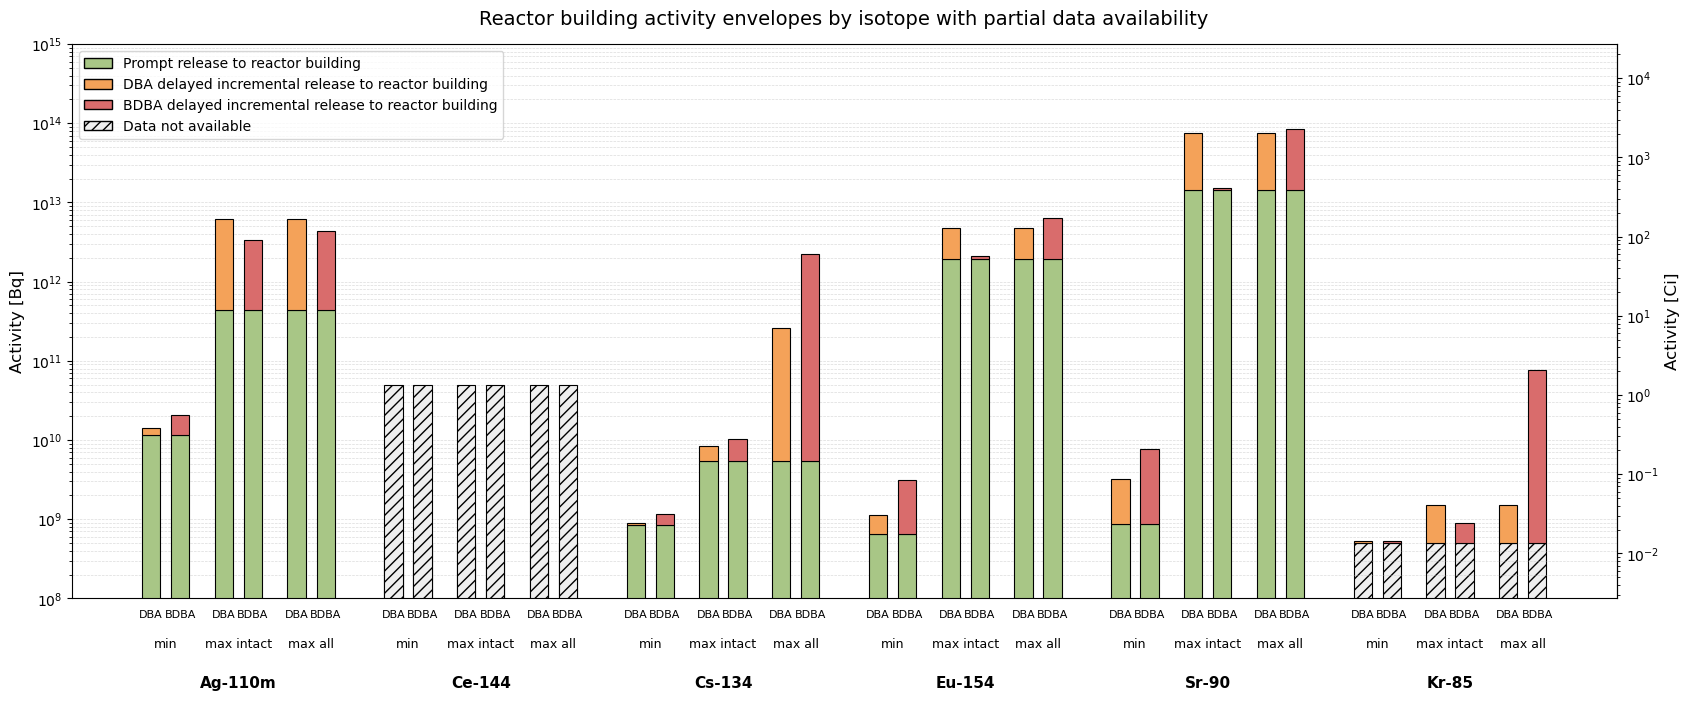

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- Labels ---
label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}

isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]
labels = [label_map.get(iso, iso) for iso in isotopes]

def get_case_value(dct, iso, case, default=0.0):
    if iso in dct and case in dct[iso]:
        return dct[iso][case]
    return default

# --- Colors ---
color_prompt = (168/255, 198/255, 134/255)   # lys grønn
color_DBA = (244/255, 162/255, 89/255)       # varm oransje
color_BDBA = (217/255, 108/255, 108/255)     # myk rød
color_missing = "#efefef"

# --- Data ---
prompt_min = np.array([get_case_value(A_building_prompt, iso, "min") for iso in isotopes])
prompt_max = np.array([get_case_value(A_building_prompt, iso, "max") for iso in isotopes])

DBA_min = np.array([get_case_value(A_building_DBA_incremental, iso, "min") for iso in isotopes])
DBA_intact = np.array([get_case_value(A_building_DBA_incremental, iso, "max_intact") for iso in isotopes])
DBA_all = np.array([get_case_value(A_building_DBA_incremental, iso, "max_all") for iso in isotopes])

BDBA_min = np.array([get_case_value(A_building_BDBA_incremental, iso, "min") for iso in isotopes])
BDBA_intact = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_intact") for iso in isotopes])
BDBA_all = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_all") for iso in isotopes])

# --- X positions ---
x = np.arange(len(isotopes))

pair_offset = 0.3
within_pair = 0.12
width = 0.075

pos_min_DBA = x - pair_offset - within_pair/2
pos_min_BDBA = x - pair_offset + within_pair/2

pos_intact_DBA = x - within_pair/2
pos_intact_BDBA = x + within_pair/2

pos_all_DBA = x + pair_offset - within_pair/2
pos_all_BDBA = x + pair_offset + within_pair/2

# --- Plot settings ---
ymin = 1e8
ymax = 1e15

KR_BASE = 5e8
CE_HATCH = 5e10

# --- Figure ---
fig, ax = plt.subplots(figsize=(17, 8), facecolor="white")
ax.set_facecolor("white")

def draw_one_bar(xpos, iso, base, increment):
    # Isotopes with prompt baseline
    if iso in A_building_prompt:
        ax.bar(xpos, base, width, color=color_prompt, edgecolor="black", linewidth=0.8, zorder=2)
        ax.bar(xpos, increment, width, bottom=base, color=current_increment_color,
               edgecolor="black", linewidth=0.8, zorder=3)
    # Kr: no prompt baseline available
    else:
        ax.bar(xpos, KR_BASE, width, color=color_missing, edgecolor="black",
               hatch="///", linewidth=0.8, zorder=1)
        ax.bar(xpos, increment, width, bottom=KR_BASE, color=current_increment_color,
               edgecolor="black", linewidth=0.8, zorder=3)

def add_ce_missing_increment(xpos, iso, base, scenario):
    if iso != "Ce144":
        return
    if scenario == "DBA" and iso not in A_building_DBA_incremental:
        ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
               edgecolor="black", hatch="///", linewidth=0.8, zorder=4)
    if scenario == "BDBA" and iso not in A_building_BDBA_incremental:
        ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
               edgecolor="black", hatch="///", linewidth=0.8, zorder=4)

# =========================
# Minimum pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_min_DBA[i], iso, prompt_min[i], DBA_min[i])
    add_ce_missing_increment(pos_min_DBA[i], iso, max(prompt_min[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_min_BDBA[i], iso, prompt_min[i], BDBA_min[i])
    add_ce_missing_increment(pos_min_BDBA[i], iso, max(prompt_min[i], ymin), "BDBA")

# =========================
# Max intact pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_intact_DBA[i], iso, prompt_max[i], DBA_intact[i])
    add_ce_missing_increment(pos_intact_DBA[i], iso, max(prompt_max[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_intact_BDBA[i], iso, prompt_max[i], BDBA_intact[i])
    add_ce_missing_increment(pos_intact_BDBA[i], iso, max(prompt_max[i], ymin), "BDBA")

# =========================
# Max all pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_all_DBA[i], iso, prompt_max[i], DBA_all[i])
    add_ce_missing_increment(pos_all_DBA[i], iso, max(prompt_max[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_all_BDBA[i], iso, prompt_max[i], BDBA_all[i])
    add_ce_missing_increment(pos_all_BDBA[i], iso, max(prompt_max[i], ymin), "BDBA")

# --- Axes ---
ax.set_xticks([])
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_ylabel("Activity [Bq]", fontsize=12)
ax.set_title("Reactor building activity envelopes by isotope with partial data availability", fontsize=14, pad=14)

# --- Grid ---
ax.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.45)

# --- Legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_prompt, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_DBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_BDBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_missing, ec="black", hatch="///"),
]
legend_labels = [
    "Prompt release to reactor building",
    "DBA delayed incremental release to reactor building",
    "BDBA delayed incremental release to reactor building",
    "Data not available"
]
ax.legend(handles, legend_labels, loc="upper left", frameon=True, fontsize=10)

# --- Scenario labels ---
for i in range(len(x)):
    ax.text(pos_min_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_min_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

    ax.text(pos_intact_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_intact_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

    ax.text(pos_all_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_all_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

# --- Envelope labels ---
for i in range(len(x)):
    ax.text(x[i] - pair_offset, -0.07, "min", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)
    ax.text(x[i], -0.07, "max intact", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)
    ax.text(x[i] + pair_offset, -0.07, "max all", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)

# --- Isotope labels ---
for i, label in enumerate(labels):
    ax.text(x[i], -0.14, label, transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=11, fontweight="bold")
    
from matplotlib.ticker import LogFormatterSciNotation

CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

ax.set_yscale("log")
ax.set_ylabel("Activity [Bq]", fontsize=12)

secax = ax.secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax.set_ylabel("Activity [Ci]", fontsize=12)
secax.yaxis.set_major_formatter(LogFormatterSciNotation())

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

### Release to the environment

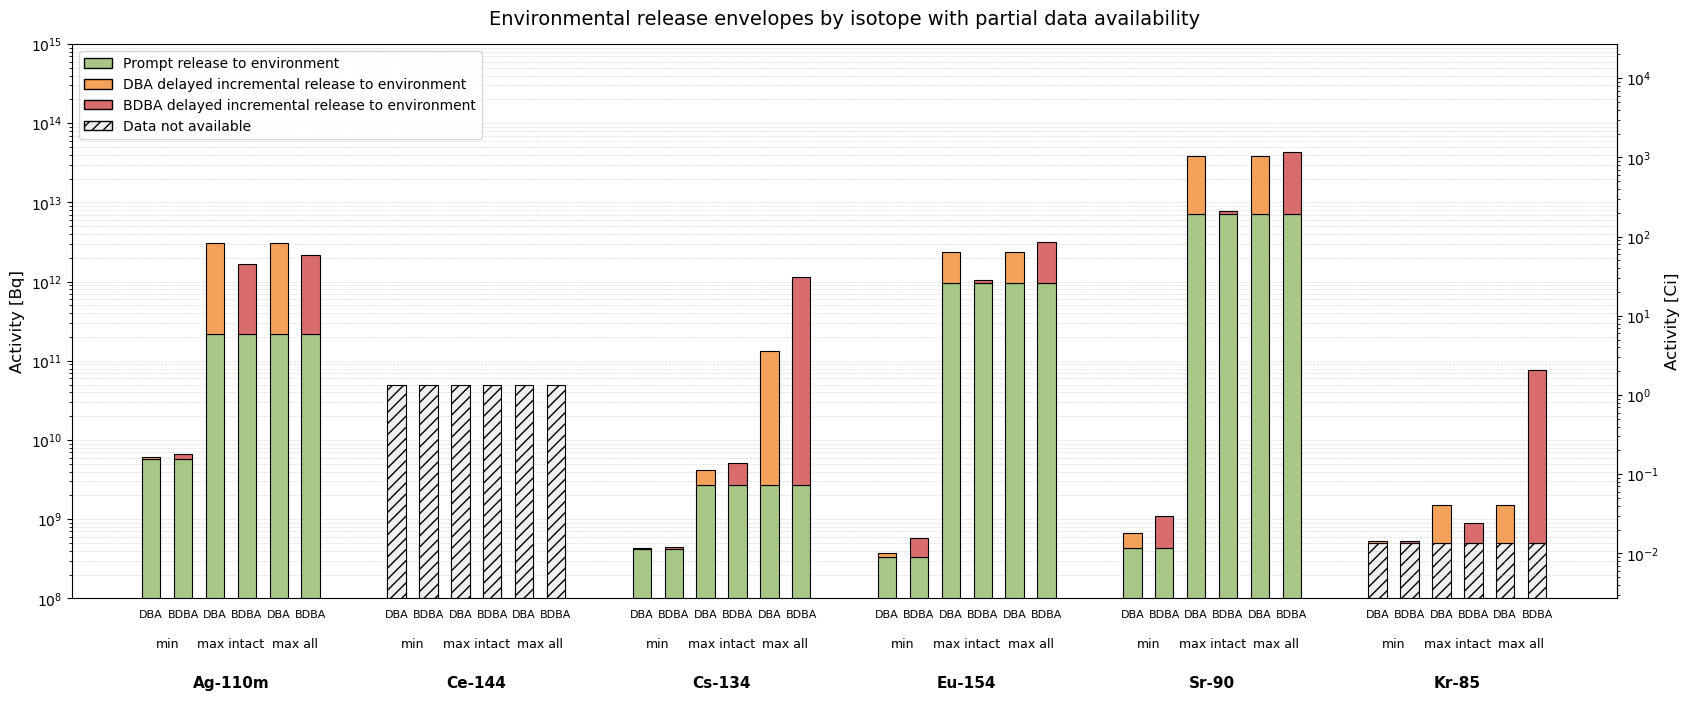

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- Labels ---
label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}

isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]
labels = [label_map.get(iso, iso) for iso in isotopes]

def get_case_value(dct, iso, case, default=0.0):
    if iso in dct and case in dct[iso]:
        return dct[iso][case]
    return default

# --- Colors ---
color_prompt = (168/255, 198/255, 134/255)   # lys grønn
color_DBA = (244/255, 162/255, 89/255)       # varm oransje
color_BDBA = (217/255, 108/255, 108/255)     # myk rød
color_missing = "#efefef"

# --- Data ---
prompt_min = np.array([get_case_value(A_environment_prompt, iso, "min") for iso in isotopes])
prompt_max = np.array([get_case_value(A_environment_prompt, iso, "max") for iso in isotopes])

DBA_min = np.array([get_case_value(A_environment_DBA_incremental, iso, "min") for iso in isotopes])
DBA_intact = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_intact") for iso in isotopes])
DBA_all = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_all") for iso in isotopes])

BDBA_min = np.array([get_case_value(A_environment_BDBA_incremental, iso, "min") for iso in isotopes])
BDBA_intact = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_intact") for iso in isotopes])
BDBA_all = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_all") for iso in isotopes])

# --- X positions ---
x = np.arange(len(isotopes))

pair_offset = 0.26
within_pair = 0.13
width = 0.075

pos_min_DBA = x - pair_offset - within_pair/2
pos_min_BDBA = x - pair_offset + within_pair/2

pos_intact_DBA = x - within_pair/2
pos_intact_BDBA = x + within_pair/2

pos_all_DBA = x + pair_offset - within_pair/2
pos_all_BDBA = x + pair_offset + within_pair/2

# --- Plot settings ---
ymin = 1e8
ymax = 1e15

KR_BASE = 5e8
CE_HATCH = 5e10

# --- Figure ---
fig, ax = plt.subplots(figsize=(17, 8), facecolor="white")
ax.set_facecolor("white")

def draw_one_bar(xpos, iso, base, increment):
    # Isotopes with prompt baseline to environment
    if iso in A_environment_prompt:
        ax.bar(xpos, base, width, color=color_prompt, edgecolor="black", linewidth=0.8, zorder=2)
        ax.bar(xpos, increment, width, bottom=base, color=current_increment_color,
               edgecolor="black", linewidth=0.8, zorder=3)
    # Kr: no prompt baseline available
    else:
        ax.bar(xpos, KR_BASE, width, color=color_missing, edgecolor="black",
               hatch="///", linewidth=0.8, zorder=1)
        ax.bar(xpos, increment, width, bottom=KR_BASE, color=current_increment_color,
               edgecolor="black", linewidth=0.8, zorder=3)

def add_ce_missing_increment(xpos, iso, base, scenario):
    if iso != "Ce144":
        return
    if scenario == "DBA" and iso not in A_environment_DBA_incremental:
        ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
               edgecolor="black", hatch="///", linewidth=0.8, zorder=4)
    if scenario == "BDBA" and iso not in A_environment_BDBA_incremental:
        ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
               edgecolor="black", hatch="///", linewidth=0.8, zorder=4)

# =========================
# Minimum pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_min_DBA[i], iso, prompt_min[i], DBA_min[i])
    add_ce_missing_increment(pos_min_DBA[i], iso, max(prompt_min[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_min_BDBA[i], iso, prompt_min[i], BDBA_min[i])
    add_ce_missing_increment(pos_min_BDBA[i], iso, max(prompt_min[i], ymin), "BDBA")

# =========================
# Max intact pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_intact_DBA[i], iso, prompt_max[i], DBA_intact[i])
    add_ce_missing_increment(pos_intact_DBA[i], iso, max(prompt_max[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_intact_BDBA[i], iso, prompt_max[i], BDBA_intact[i])
    add_ce_missing_increment(pos_intact_BDBA[i], iso, max(prompt_max[i], ymin), "BDBA")

# =========================
# Max all pair
# =========================
for i, iso in enumerate(isotopes):
    current_increment_color = color_DBA
    draw_one_bar(pos_all_DBA[i], iso, prompt_max[i], DBA_all[i])
    add_ce_missing_increment(pos_all_DBA[i], iso, max(prompt_max[i], ymin), "DBA")

    current_increment_color = color_BDBA
    draw_one_bar(pos_all_BDBA[i], iso, prompt_max[i], BDBA_all[i])
    add_ce_missing_increment(pos_all_BDBA[i], iso, max(prompt_max[i], ymin), "BDBA")

# --- Axes ---
ax.set_xticks([])
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_ylabel("Activity [Bq]", fontsize=12)
ax.set_title("Environmental release envelopes by isotope with partial data availability", fontsize=14, pad=14)

# --- Grid ---
ax.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.45)

# --- Legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_prompt, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_DBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_BDBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_missing, ec="black", hatch="///"),
]
legend_labels = [
    "Prompt release to environment",
    "DBA delayed incremental release to environment",
    "BDBA delayed incremental release to environment",
    "Data not available"
]
ax.legend(handles, legend_labels, loc="upper left", frameon=True, fontsize=10)

# --- Scenario labels ---
for i in range(len(x)):
    ax.text(pos_min_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_min_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

    ax.text(pos_intact_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_intact_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

    ax.text(pos_all_DBA[i], -0.02, "DBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)
    ax.text(pos_all_BDBA[i], -0.02, "BDBA", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8)

# --- Envelope labels ---
for i in range(len(x)):
    ax.text(x[i] - pair_offset, -0.07, "min", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)
    ax.text(x[i], -0.07, "max intact", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)
    ax.text(x[i] + pair_offset, -0.07, "max all", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9)

# --- Isotope labels ---
for i, label in enumerate(labels):
    ax.text(x[i], -0.14, label, transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=11, fontweight="bold")
    
from matplotlib.ticker import LogFormatterSciNotation

CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

ax.set_yscale("log")
ax.set_ylabel("Activity [Bq]", fontsize=12)

secax = ax.secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax.set_ylabel("Activity [Ci]", fontsize=12)
secax.yaxis.set_major_formatter(LogFormatterSciNotation())

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

### total release (samlefigur - crowoded)

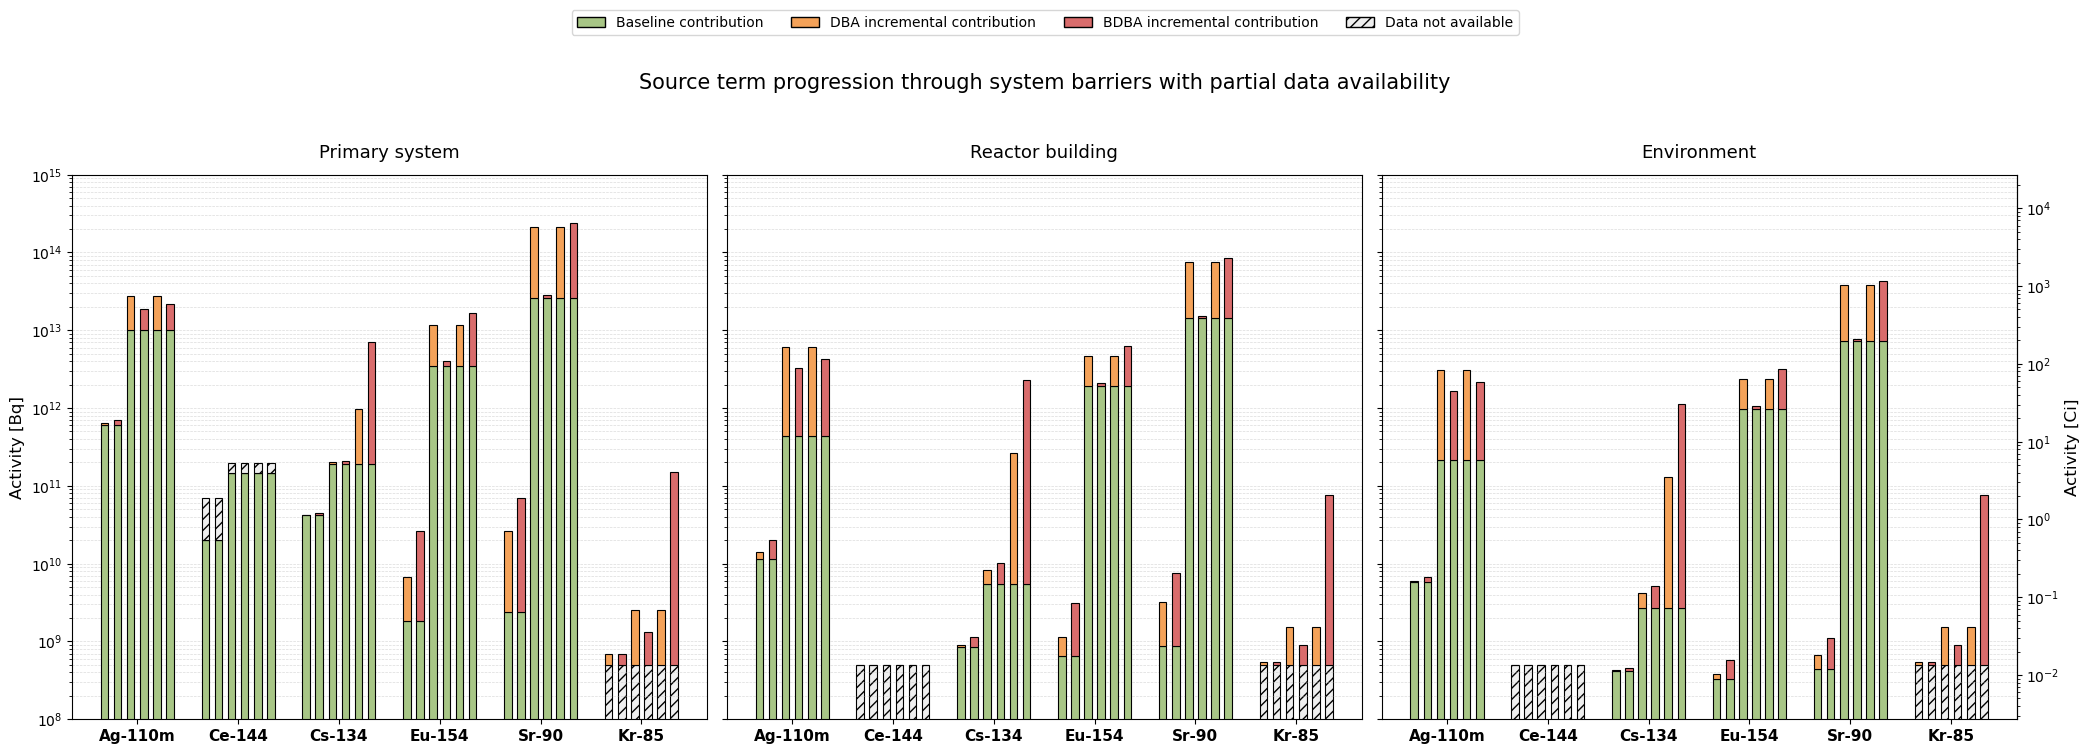

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogFormatterSciNotation

# --- Penere isotopnavn ---
label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}

# --- Isotoper vi vil vise ---
isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Hjelpefunksjon ---
def get_case_value(dct, iso, case, default=0.0):
    if iso in dct and case in dct[iso]:
        return dct[iso][case]
    return default

# --- Farger ---
color_base = (168/255, 198/255, 134/255)   # lys grønn
color_DBA = (244/255, 162/255, 89/255)     # varm oransje
color_BDBA = (217/255, 108/255, 108/255)   # myk rød
color_missing = "#efefef"

# --- X-posisjoner ---
x = np.arange(len(isotopes))
pair_offset = 0.26
within_pair = 0.13
width = 0.075

pos_min_DBA = x - pair_offset - within_pair/2
pos_min_BDBA = x - pair_offset + within_pair/2

pos_intact_DBA = x - within_pair/2
pos_intact_BDBA = x + within_pair/2

pos_all_DBA = x + pair_offset - within_pair/2
pos_all_BDBA = x + pair_offset + within_pair/2

# --- Felles y-aksegrenser ---
ymin = 1e8
ymax = 1e15

# --- Hatch-høyder ---
KR_BASE = 5e8
CE_HATCH = 5e10

# --- Curie-konvertering ---
CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

def draw_panel(ax, base_min, base_max, dba_min, dba_intact, dba_all,
               bdba_min, bdba_intact, bdba_all,
               base_dict, dba_dict, bdba_dict,
               title, ylabel=None):

    ax.set_facecolor("white")

    def draw_one_bar(xpos, iso, base, increment, increment_color):
        # Har baseline
        if iso in base_dict:
            ax.bar(xpos, base, width, color=color_base, edgecolor="black",
                   linewidth=0.8, zorder=2)
            ax.bar(xpos, increment, width, bottom=base, color=increment_color,
                   edgecolor="black", linewidth=0.8, zorder=3)
        # Mangler baseline -> hatch nederst
        else:
            ax.bar(xpos, KR_BASE, width, color=color_missing, edgecolor="black",
                   hatch="///", linewidth=0.8, zorder=1)
            ax.bar(xpos, increment, width, bottom=KR_BASE, color=increment_color,
                   edgecolor="black", linewidth=0.8, zorder=3)

    def add_missing_increment(xpos, iso, base, scenario):
        # Hvis baseline finnes men scenario-data mangler, legg hatch over basen
        if iso in base_dict:
            if scenario == "DBA" and iso not in dba_dict:
                ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
                       edgecolor="black", hatch="///", linewidth=0.8, zorder=4)
            if scenario == "BDBA" and iso not in bdba_dict:
                ax.bar(xpos, CE_HATCH, width, bottom=base, color=color_missing,
                       edgecolor="black", hatch="///", linewidth=0.8, zorder=4)

    # Minimum
    for i, iso in enumerate(isotopes):
        draw_one_bar(pos_min_DBA[i], iso, base_min[i], dba_min[i], color_DBA)
        add_missing_increment(pos_min_DBA[i], iso, max(base_min[i], ymin), "DBA")

        draw_one_bar(pos_min_BDBA[i], iso, base_min[i], bdba_min[i], color_BDBA)
        add_missing_increment(pos_min_BDBA[i], iso, max(base_min[i], ymin), "BDBA")

    # Max intact
    for i, iso in enumerate(isotopes):
        draw_one_bar(pos_intact_DBA[i], iso, base_max[i], dba_intact[i], color_DBA)
        add_missing_increment(pos_intact_DBA[i], iso, max(base_max[i], ymin), "DBA")

        draw_one_bar(pos_intact_BDBA[i], iso, base_max[i], bdba_intact[i], color_BDBA)
        add_missing_increment(pos_intact_BDBA[i], iso, max(base_max[i], ymin), "BDBA")

    # Max all
    for i, iso in enumerate(isotopes):
        draw_one_bar(pos_all_DBA[i], iso, base_max[i], dba_all[i], color_DBA)
        add_missing_increment(pos_all_DBA[i], iso, max(base_max[i], ymin), "DBA")

        draw_one_bar(pos_all_BDBA[i], iso, base_max[i], bdba_all[i], color_BDBA)
        add_missing_increment(pos_all_BDBA[i], iso, max(base_max[i], ymin), "BDBA")

    # --- Aksene ---
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=13, pad=12)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)

    ax.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.45)

    # --- Kun isotopnavn ---
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11, fontweight="bold")


# =========================
# DATA: Primary system
# =========================
primary_base_min = np.array([get_case_value(A_primary_NO, iso, "min") for iso in isotopes])
primary_base_max = np.array([get_case_value(A_primary_NO, iso, "max") for iso in isotopes])

primary_DBA_min = np.array([get_case_value(A_primary_DBA, iso, "min") for iso in isotopes])
primary_DBA_intact = np.array([get_case_value(A_primary_DBA, iso, "max_intact") for iso in isotopes])
primary_DBA_all = np.array([get_case_value(A_primary_DBA, iso, "max_all") for iso in isotopes])

primary_BDBA_min = np.array([get_case_value(A_primary_BDBA, iso, "min") for iso in isotopes])
primary_BDBA_intact = np.array([get_case_value(A_primary_BDBA, iso, "max_intact") for iso in isotopes])
primary_BDBA_all = np.array([get_case_value(A_primary_BDBA, iso, "max_all") for iso in isotopes])

# =========================
# DATA: Reactor building
# =========================
building_base_min = np.array([get_case_value(A_building_prompt, iso, "min") for iso in isotopes])
building_base_max = np.array([get_case_value(A_building_prompt, iso, "max") for iso in isotopes])

building_DBA_min = np.array([get_case_value(A_building_DBA_incremental, iso, "min") for iso in isotopes])
building_DBA_intact = np.array([get_case_value(A_building_DBA_incremental, iso, "max_intact") for iso in isotopes])
building_DBA_all = np.array([get_case_value(A_building_DBA_incremental, iso, "max_all") for iso in isotopes])

building_BDBA_min = np.array([get_case_value(A_building_BDBA_incremental, iso, "min") for iso in isotopes])
building_BDBA_intact = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_intact") for iso in isotopes])
building_BDBA_all = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_all") for iso in isotopes])

# =========================
# DATA: Environment
# =========================
env_base_min = np.array([get_case_value(A_environment_prompt, iso, "min") for iso in isotopes])
env_base_max = np.array([get_case_value(A_environment_prompt, iso, "max") for iso in isotopes])

env_DBA_min = np.array([get_case_value(A_environment_DBA_incremental, iso, "min") for iso in isotopes])
env_DBA_intact = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_intact") for iso in isotopes])
env_DBA_all = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_all") for iso in isotopes])

env_BDBA_min = np.array([get_case_value(A_environment_BDBA_incremental, iso, "min") for iso in isotopes])
env_BDBA_intact = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_intact") for iso in isotopes])
env_BDBA_all = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_all") for iso in isotopes])

# =========================
# FIGUR
# =========================
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True, facecolor="white")

draw_panel(
    axes[0],
    primary_base_min, primary_base_max,
    primary_DBA_min, primary_DBA_intact, primary_DBA_all,
    primary_BDBA_min, primary_BDBA_intact, primary_BDBA_all,
    A_primary_NO, A_primary_DBA, A_primary_BDBA,
    "Primary system",
    ylabel="Activity [Bq]"
)

draw_panel(
    axes[1],
    building_base_min, building_base_max,
    building_DBA_min, building_DBA_intact, building_DBA_all,
    building_BDBA_min, building_BDBA_intact, building_BDBA_all,
    A_building_prompt, A_building_DBA_incremental, A_building_BDBA_incremental,
    "Reactor building"
)

draw_panel(
    axes[2],
    env_base_min, env_base_max,
    env_DBA_min, env_DBA_intact, env_DBA_all,
    env_BDBA_min, env_BDBA_intact, env_BDBA_all,
    A_environment_prompt, A_environment_DBA_incremental, A_environment_BDBA_incremental,
    "Environment"
)

# --- Sekundær y-akse (kun høyre panel) ---
secax = axes[2].secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax.set_ylabel("Activity [Ci]", fontsize=12)
secax.yaxis.set_major_formatter(LogFormatterSciNotation())

# --- Legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_base, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_DBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_BDBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_missing, ec="black", hatch="///"),
]

labels_legend = [
    "Baseline contribution",
    "DBA incremental contribution",
    "BDBA incremental contribution",
    "Data not available"
]

fig.legend(
    handles, labels_legend,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.08),
    frameon=True
)

fig.suptitle("Source term progression through system barriers with partial data availability", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Source term progression through successive containment barriers for selected fission products. The panels show activity released to the primary system (left), reactor building (middle), and environment (right). For each isotope, release envelopes are constructed from minimum and maximum experimental release fractions, where maximum values distinguish between intact compacts and all compacts, including defective particles. The green bars represent the baseline contribution, corresponding to pre-existing primary system inventory for the primary system and prompt release for downstream barriers. The orange and red bars represent incremental delayed contributions from design basis accident (DBA) and beyond design basis accident (BDBA) scenarios, respectively. The figure illustrates how both barrier performance and accident severity influence the magnitude and composition of the resulting source term. 

### Total release fractions to env

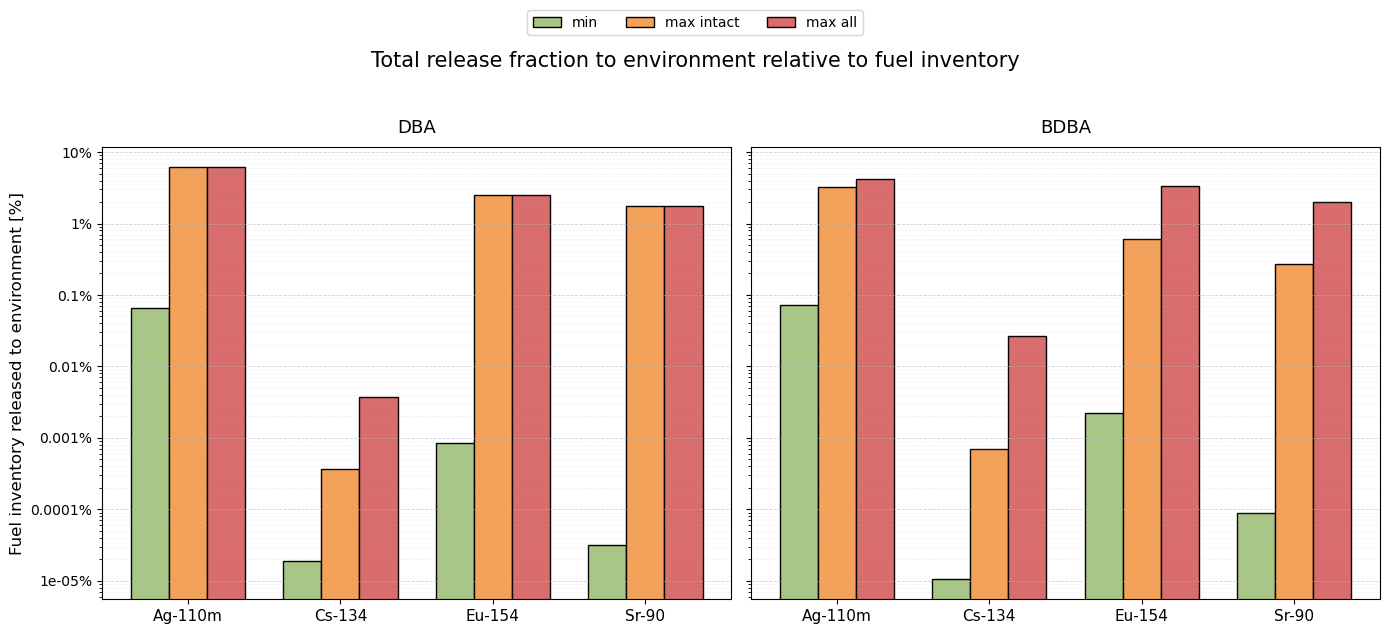

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, FuncFormatter

# --- Penere isotopnavn ---
label_map = {
    "Ag110m": "Ag-110m",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90"
}

isotopes = list(A_environment_DBA_total.keys())
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Farger ---
color_min = "#A8C686"      # lys grønn
color_intact = "#F4A259"   # varm oransje
color_all = "#D96C6C"      # myk rød

# =========================
# DBA ratios (%)
# =========================
ratio_min_DBA = []
ratio_intact_DBA = []
ratio_all_DBA = []

for iso in isotopes:
    ratio_min_DBA.append(
        100 * A_environment_DBA_total[iso]["min"] /
        fuel_inventory_RF_DBA[iso]["min"]["activity"]
    )
    ratio_intact_DBA.append(
        100 * A_environment_DBA_total[iso]["max_intact"] /
        fuel_inventory_RF_DBA[iso]["max_intact"]["activity"]
    )
    ratio_all_DBA.append(
        100 * A_environment_DBA_total[iso]["max_all"] /
        fuel_inventory_RF_DBA[iso]["max_all"]["activity"]
    )

# =========================
# BDBA ratios (%)
# =========================
ratio_min_BDBA = []
ratio_intact_BDBA = []
ratio_all_BDBA = []

for iso in isotopes:
    ratio_min_BDBA.append(
        100 * A_environment_BDBA_total[iso]["min"] /
        fuel_inventory_RF_BDBA[iso]["min"]["activity"]
    )
    ratio_intact_BDBA.append(
        100 * A_environment_BDBA_total[iso]["max_intact"] /
        fuel_inventory_RF_BDBA[iso]["max_intact"]["activity"]
    )
    ratio_all_BDBA.append(
        100 * A_environment_BDBA_total[iso]["max_all"] /
        fuel_inventory_RF_BDBA[iso]["max_all"]["activity"]
    )

# --- X-akse ---
x = np.arange(len(isotopes))
width = 0.25

# =========================
# Formatter for %
# =========================
def percent_formatter(x, pos):
    return f"{x:.3g}%"

# =========================
# Figur
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, facecolor="white")

def draw_ratio_panel(ax, ratio_min, ratio_intact, ratio_all, title, ylabel=None):
    ax.set_facecolor("white")

    ax.bar(x - width, ratio_min, width, label="min", color=color_min, edgecolor="black")
    ax.bar(x, ratio_intact, width, label="max intact", color=color_intact, edgecolor="black")
    ax.bar(x + width, ratio_all, width, label="max all", color=color_all, edgecolor="black")

    # --- Log scale ---
    ax.set_yscale("log")

    # --- Prosent ticks ---
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)*0.1))
    ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

    # --- Grid ---
    ax.grid(axis="y", which="major", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.4, alpha=0.4)

    # --- Labels ---
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    if ylabel:
        ax.set_ylabel("Fuel inventory released to environment [%]", fontsize=12)

# --- Tegn paneler ---
draw_ratio_panel(
    axes[0],
    ratio_min_DBA, ratio_intact_DBA, ratio_all_DBA,
    "DBA",
    ylabel="Fuel inventory released to environment [%]"
)

draw_ratio_panel(
    axes[1],
    ratio_min_BDBA, ratio_intact_BDBA, ratio_all_BDBA,
    "BDBA"
)

# --- Felles legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_min, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_intact, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_all, ec="black"),
]
legend_labels = ["min", "max intact", "max all"]

fig.legend(handles, legend_labels, loc="upper center", ncol=3,
           bbox_to_anchor=(0.5, 1.06), frameon=True)

fig.suptitle("Total release fraction to environment relative to fuel inventory", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Fraction of fuel inventory released to the environment for selected isotopes under design basis accident (DBA) conditions. For each isotope, three bars are shown corresponding to minimum, maximum intact, and maximum all release envelopes. The ratios are calculated as the total activity released to the environment divided by the burnup-matched fuel inventory used for each corresponding DBA case.

Fraction of activity released to the environment relative to the total activity in the primary system for selected isotopes under design basis accident (DBA) conditions. For each isotope, three bars are shown corresponding to minimum, maximum intact, and maximum all release envelopes. The ratios represent the combined attenuation effect of the helium pressure boundary and reactor building, calculated as the total activity released to the environment divided by the total activity in the primary system.

### Prompt vs delayed contribution

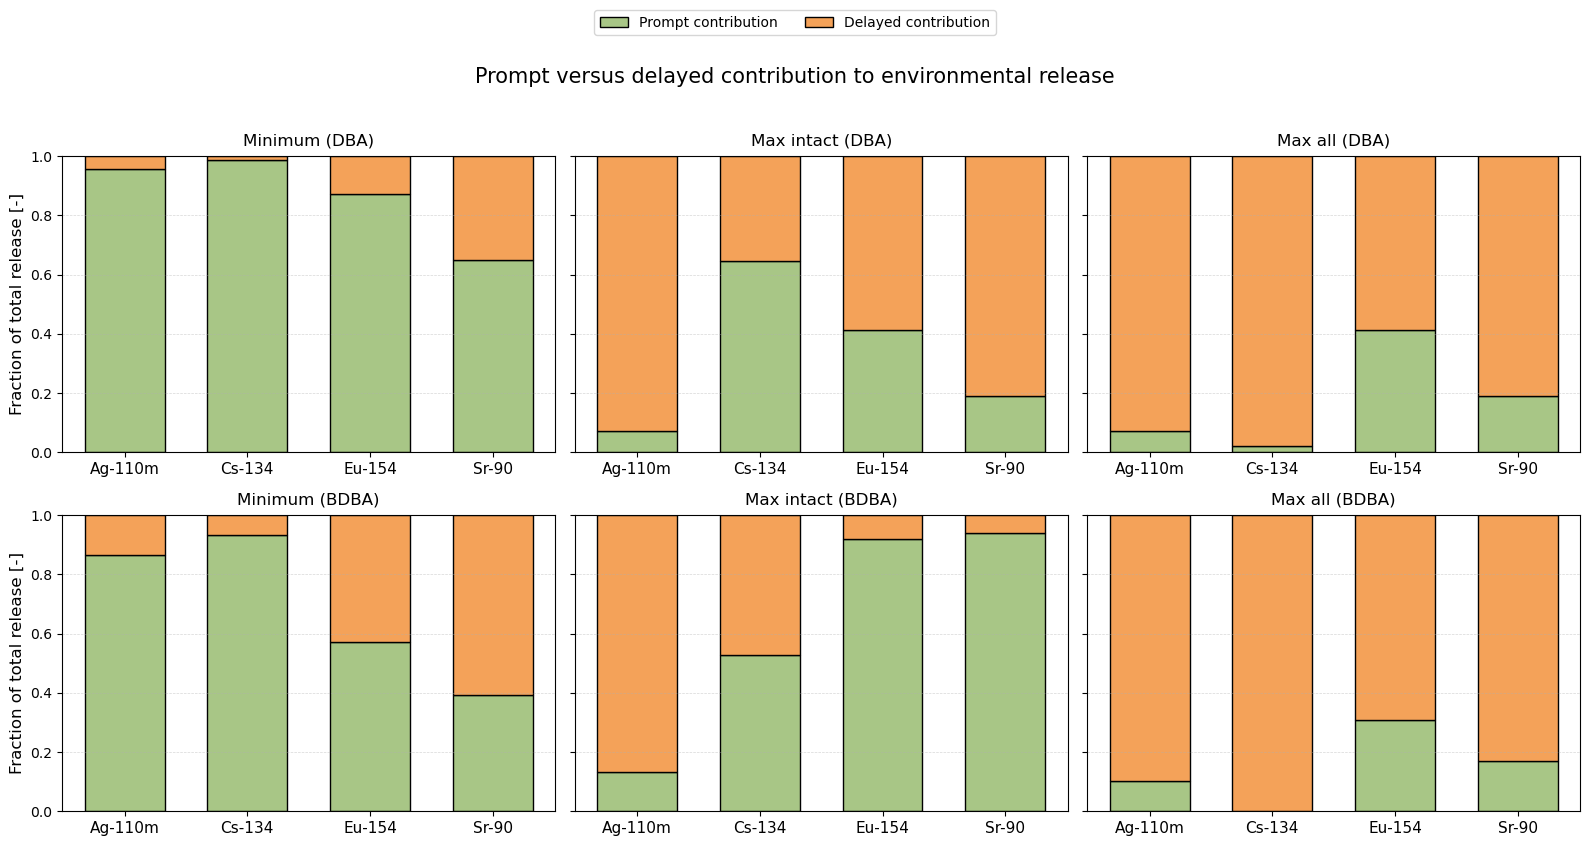

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- Isotoper med komplett kjede ---
isotopes = isotopes_full

label_map = {
    "Ag110m": "Ag-110m",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90"
}
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Farger ---
color_prompt = "#A8C686"   # lys grønn
color_delayed = "#F4A259"  # varm oransje

# =========================
# Hjelpefunksjon
# =========================
def get_prompt_delayed_fractions(total_dict, prompt_dict, delayed_dict, case_total, case_prompt, case_delayed):
    prompt_frac = []
    delayed_frac = []

    for iso in isotopes:
        total = total_dict[iso][case_total]
        prompt = prompt_dict[iso][case_prompt]
        delayed = delayed_dict[iso][case_delayed]

        prompt_frac.append(prompt / total)
        delayed_frac.append(delayed / total)

    return np.array(prompt_frac), np.array(delayed_frac)

# =========================
# DBA fractions
# =========================
prompt_min_DBA, delayed_min_DBA = get_prompt_delayed_fractions(
    A_environment_DBA_total, A_environment_prompt, A_environment_DBA_incremental,
    case_total="min", case_prompt="min", case_delayed="min"
)

prompt_intact_DBA, delayed_intact_DBA = get_prompt_delayed_fractions(
    A_environment_DBA_total, A_environment_prompt, A_environment_DBA_incremental,
    case_total="max_intact", case_prompt="max", case_delayed="max_intact"
)

prompt_all_DBA, delayed_all_DBA = get_prompt_delayed_fractions(
    A_environment_DBA_total, A_environment_prompt, A_environment_DBA_incremental,
    case_total="max_all", case_prompt="max", case_delayed="max_all"
)

# =========================
# BDBA fractions
# =========================
prompt_min_BDBA, delayed_min_BDBA = get_prompt_delayed_fractions(
    A_environment_BDBA_total, A_environment_prompt, A_environment_BDBA_incremental,
    case_total="min", case_prompt="min", case_delayed="min"
)

prompt_intact_BDBA, delayed_intact_BDBA = get_prompt_delayed_fractions(
    A_environment_BDBA_total, A_environment_prompt, A_environment_BDBA_incremental,
    case_total="max_intact", case_prompt="max", case_delayed="max_intact"
)

prompt_all_BDBA, delayed_all_BDBA = get_prompt_delayed_fractions(
    A_environment_BDBA_total, A_environment_prompt, A_environment_BDBA_incremental,
    case_total="max_all", case_prompt="max", case_delayed="max_all"
)

# =========================
# Figur
# =========================
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True, facecolor="white")

x = np.arange(len(isotopes))
width = 0.65

def draw_fraction_panel(ax, prompt_frac, delayed_frac, title, ylabel=None):
    ax.set_facecolor("white")

    ax.bar(x, prompt_frac, width, color=color_prompt, edgecolor="black", label="Prompt")
    ax.bar(x, delayed_frac, width, bottom=prompt_frac, color=color_delayed, edgecolor="black", label="Delayed")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_title(title, fontsize=12, pad=8)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)

    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# --- Øverste rad: DBA ---
draw_fraction_panel(axes[0, 0], prompt_min_DBA, delayed_min_DBA, "Minimum (DBA)", ylabel="Fraction of total release [-]")
draw_fraction_panel(axes[0, 1], prompt_intact_DBA, delayed_intact_DBA, "Max intact (DBA)")
draw_fraction_panel(axes[0, 2], prompt_all_DBA, delayed_all_DBA, "Max all (DBA)")

# --- Nederste rad: BDBA ---
draw_fraction_panel(axes[1, 0], prompt_min_BDBA, delayed_min_BDBA, "Minimum (BDBA)", ylabel="Fraction of total release [-]")
draw_fraction_panel(axes[1, 1], prompt_intact_BDBA, delayed_intact_BDBA, "Max intact (BDBA)")
draw_fraction_panel(axes[1, 2], prompt_all_BDBA, delayed_all_BDBA, "Max all (BDBA)")

# --- Legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_prompt, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_delayed, ec="black"),
]
legend_labels = ["Prompt contribution", "Delayed contribution"]

fig.legend(handles, legend_labels, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.06), frameon=True)

fig.suptitle("Prompt versus delayed contribution to environmental release", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### DBA vs BDBA incremental release

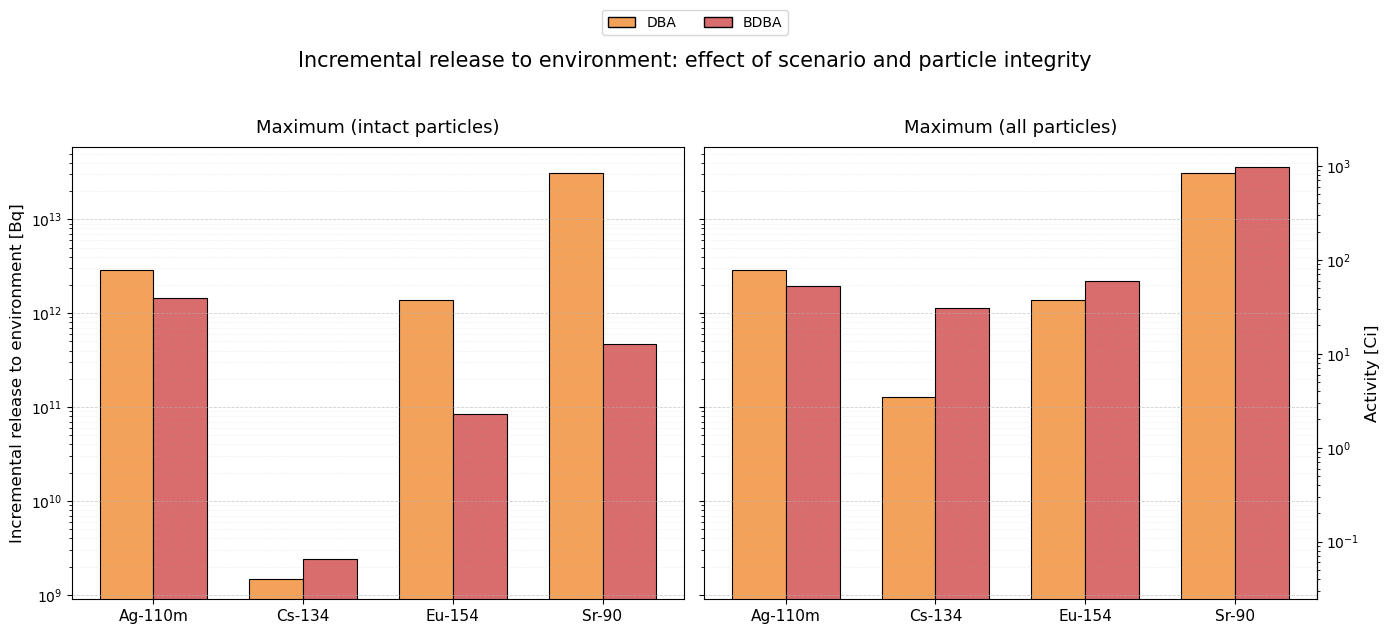

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

# --- Penere isotopnavn ---
label_map = {
    "Ag110m": "Ag-110m",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90"
}

isotopes = isotopes_full
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Farger (konsistent med resten) ---
color_DBA = (244/255, 162/255, 89/255)   # oransje
color_BDBA = (217/255, 108/255, 108/255) # rød

# =========================
# Data
# =========================
DBA_intact = []
BDBA_intact = []
DBA_all = []
BDBA_all = []

for iso in isotopes:
    DBA_intact.append(A_environment_DBA_incremental[iso]["max_intact"])
    BDBA_intact.append(A_environment_BDBA_incremental[iso]["max_intact"])

    DBA_all.append(A_environment_DBA_incremental[iso]["max_all"])
    BDBA_all.append(A_environment_BDBA_incremental[iso]["max_all"])

DBA_intact = np.array(DBA_intact)
BDBA_intact = np.array(BDBA_intact)
DBA_all = np.array(DBA_all)
BDBA_all = np.array(BDBA_all)

# --- X ---
x = np.arange(len(isotopes))
width = 0.36

# --- Konvertering ---
CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

# =========================
# Figur
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, facecolor="white")

def draw_panel(ax, vals_DBA, vals_BDBA, title, ylabel=None):
    ax.set_facecolor("white")

    ax.bar(x - width/2, vals_DBA, width,
           color=color_DBA, edgecolor="black", linewidth=0.8, label="DBA")

    ax.bar(x + width/2, vals_BDBA, width,
           color=color_BDBA, edgecolor="black", linewidth=0.8, label="BDBA")

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)

    if ylabel:
        ax.set_ylabel("Incremental release to environment [Bq]", fontsize=12)

    # --- Grid ---
    ax.grid(axis="y", which="major", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.4, alpha=0.4)

    # --- Log ticks ---
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation())
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1,10)*0.1))

# --- Paneler ---
draw_panel(
    axes[0],
    DBA_intact, BDBA_intact,
    "Maximum (intact particles)",
    ylabel="Incremental release to environment [Bq]"
)

draw_panel(
    axes[1],
    DBA_all, BDBA_all,
    "Maximum (all particles)"
)

# =========================
# Sekundærakse (kun høyre panel)
# =========================
secax = axes[1].secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax.set_ylabel("Activity [Ci]", fontsize=12)
secax.yaxis.set_major_formatter(LogFormatterSciNotation())

# --- Legend ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_DBA, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_BDBA, ec="black"),
]

fig.legend(handles, ["DBA", "BDBA"],
           loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.06), frameon=True)

fig.suptitle("Incremental release to environment: effect of scenario and particle integrity", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Source term progression through system barriers for DBA (top row) and BDBA (bottom row) scenarios. Columns correspond to minimum, maximum intact, and maximum all cases. For each isotope, bars represent fuel inventory, primary system, reactor building, and environmental activity. Activities are shown on a logarithmic scale with a secondary axis in curies (Ci)

### Progression (all)

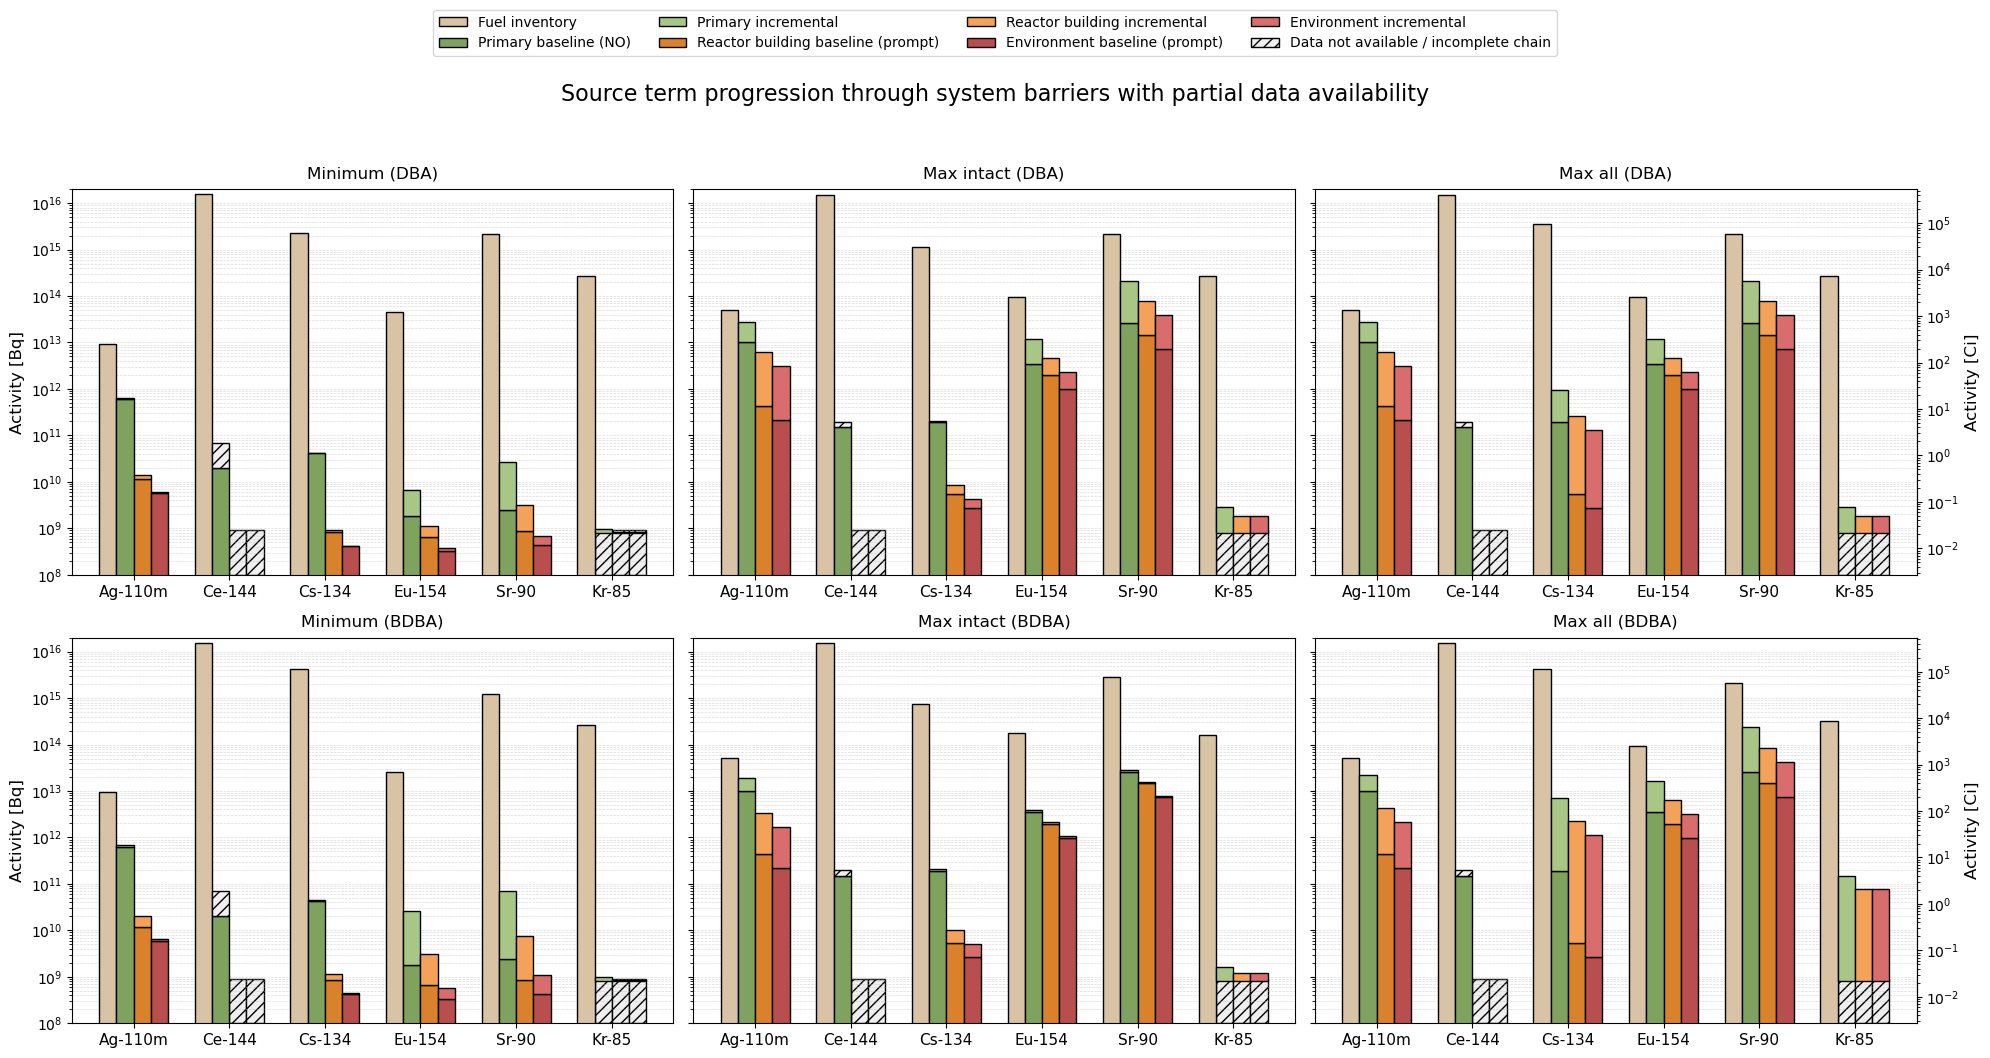

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogFormatterSciNotation

# --- Isotoper vi vil vise ---
isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]

label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Hjelpefunksjon ---
def get_case_value(dct, iso, case, default=0.0):
    if iso in dct and case in dct[iso]:
        return dct[iso][case]
    return default

# --- Farger ---
color_fuel = "#D8C3A5"

color_primary_base = "#7FA35E"
color_primary_inc  = "#A8C686"

color_building_base = "#D9822B"
color_building_inc  = "#F4A259"

color_env_base = "#B84E4E"
color_env_inc  = "#D96C6C"

color_missing = "#EFEFEF"

# --- Curie conversion ---
CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

# --- X-akse ---
x = np.arange(len(isotopes))
width = 0.18

# --- Aksegrenser / hatch-høyder ---
ymin = 1e8
ymax = 2e16
HATCH_H = 8e8          # for manglende hele ledd / manglende baseline
HATCH_H_INC = 5e10     # for manglende incremental over kjent baseline

# =========================
# NO / baseline data
# =========================
fuel_min_NO = np.array([get_case_value(fuel_inventory_RF_NO, iso, "min", {}).get("activity", 0.0) for iso in isotopes])
fuel_max_NO = np.array([get_case_value(fuel_inventory_RF_NO, iso, "max", {}).get("activity", 0.0) for iso in isotopes])

primary_min_NO = np.array([get_case_value(A_primary_NO, iso, "min") for iso in isotopes])
primary_max_NO = np.array([get_case_value(A_primary_NO, iso, "max") for iso in isotopes])

building_min_NO = np.array([get_case_value(A_building_prompt, iso, "min") for iso in isotopes])
building_max_NO = np.array([get_case_value(A_building_prompt, iso, "max") for iso in isotopes])

env_min_NO = np.array([get_case_value(A_environment_prompt, iso, "min") for iso in isotopes])
env_max_NO = np.array([get_case_value(A_environment_prompt, iso, "max") for iso in isotopes])

# =========================
# DBA incremental data
# =========================
fuel_min_DBA = np.array([get_case_value(fuel_inventory_RF_DBA, iso, "min", {}).get("activity", 0.0) for iso in isotopes])
fuel_intact_DBA = np.array([get_case_value(fuel_inventory_RF_DBA, iso, "max_intact", {}).get("activity", 0.0) for iso in isotopes])
fuel_all_DBA = np.array([get_case_value(fuel_inventory_RF_DBA, iso, "max_all", {}).get("activity", 0.0) for iso in isotopes])

primary_min_DBA_inc = np.array([get_case_value(A_primary_DBA, iso, "min") for iso in isotopes])
primary_intact_DBA_inc = np.array([get_case_value(A_primary_DBA, iso, "max_intact") for iso in isotopes])
primary_all_DBA_inc = np.array([get_case_value(A_primary_DBA, iso, "max_all") for iso in isotopes])

building_min_DBA_inc = np.array([get_case_value(A_building_DBA_incremental, iso, "min") for iso in isotopes])
building_intact_DBA_inc = np.array([get_case_value(A_building_DBA_incremental, iso, "max_intact") for iso in isotopes])
building_all_DBA_inc = np.array([get_case_value(A_building_DBA_incremental, iso, "max_all") for iso in isotopes])

env_min_DBA_inc = np.array([get_case_value(A_environment_DBA_incremental, iso, "min") for iso in isotopes])
env_intact_DBA_inc = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_intact") for iso in isotopes])
env_all_DBA_inc = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_all") for iso in isotopes])

# =========================
# BDBA incremental data
# =========================
fuel_min_BDBA = np.array([get_case_value(fuel_inventory_RF_BDBA, iso, "min", {}).get("activity", 0.0) for iso in isotopes])
fuel_intact_BDBA = np.array([get_case_value(fuel_inventory_RF_BDBA, iso, "max_intact", {}).get("activity", 0.0) for iso in isotopes])
fuel_all_BDBA = np.array([get_case_value(fuel_inventory_RF_BDBA, iso, "max_all", {}).get("activity", 0.0) for iso in isotopes])

primary_min_BDBA_inc = np.array([get_case_value(A_primary_BDBA, iso, "min") for iso in isotopes])
primary_intact_BDBA_inc = np.array([get_case_value(A_primary_BDBA, iso, "max_intact") for iso in isotopes])
primary_all_BDBA_inc = np.array([get_case_value(A_primary_BDBA, iso, "max_all") for iso in isotopes])

building_min_BDBA_inc = np.array([get_case_value(A_building_BDBA_incremental, iso, "min") for iso in isotopes])
building_intact_BDBA_inc = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_intact") for iso in isotopes])
building_all_BDBA_inc = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_all") for iso in isotopes])

env_min_BDBA_inc = np.array([get_case_value(A_environment_BDBA_incremental, iso, "min") for iso in isotopes])
env_intact_BDBA_inc = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_intact") for iso in isotopes])
env_all_BDBA_inc = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_all") for iso in isotopes])

# =========================
# Ce from NO only
# =========================
ce_no = {
    "min": {
        "fuel": fuel_inventory_RF_NO["Ce144"]["min"]["activity"],
        "primary": A_primary_NO["Ce144"]["min"],
    },
    "intact": {
        "fuel": fuel_inventory_RF_NO["Ce144"]["max"]["activity"],
        "primary": A_primary_NO["Ce144"]["max"],
    },
    "all": {
        "fuel": fuel_inventory_RF_NO["Ce144"]["max"]["activity"],
        "primary": A_primary_NO["Ce144"]["max"],
    }
}

# =========================
# FIGUR
# =========================
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True, facecolor="white")

def draw_panel(ax, fuel_vals, primary_base, primary_inc, building_base, building_inc, env_base, env_inc,
               title, case_key):
    ax.set_facecolor("white")

    xpos_fuel = x - 1.5 * width
    xpos_primary = x - 0.5 * width
    xpos_building = x + 0.5 * width
    xpos_env = x + 1.5 * width

    for i, iso in enumerate(isotopes):
        # --- Fuel inventory: never stacked ---
        if iso == "Ce144":
            ax.bar(xpos_fuel[i], ce_no[case_key]["fuel"], width,
                   color=color_fuel, edgecolor="black", zorder=2)
        elif fuel_vals[i] > 0:
            ax.bar(xpos_fuel[i], fuel_vals[i], width,
                   color=color_fuel, edgecolor="black", zorder=2)
        else:
            ax.bar(xpos_fuel[i], HATCH_H, width, bottom=ymin,
                   color=color_missing, edgecolor="black", hatch="///", zorder=1)

        # --- Primary system ---
        if iso == "Kr85":
            ax.bar(xpos_primary[i], HATCH_H, width, bottom=ymin,
                   color=color_missing, edgecolor="black", hatch="///", zorder=1)
            ax.bar(xpos_primary[i], primary_inc[i], width, bottom=HATCH_H,
                   color=color_primary_inc, edgecolor="black", zorder=2)

        elif iso == "Ce144":
            ax.bar(xpos_primary[i], ce_no[case_key]["primary"], width,
                   color=color_primary_base, edgecolor="black", zorder=2)
            ax.bar(xpos_primary[i], HATCH_H_INC, width, bottom=ce_no[case_key]["primary"],
                   color=color_missing, edgecolor="black", hatch="///", zorder=3)

        else:
            ax.bar(xpos_primary[i], primary_base[i], width,
                   color=color_primary_base, edgecolor="black", zorder=2)
            ax.bar(xpos_primary[i], primary_inc[i], width, bottom=primary_base[i],
                   color=color_primary_inc, edgecolor="black", zorder=3)

        # --- Reactor building ---
        if iso == "Ce144":
            ax.bar(xpos_building[i], HATCH_H, width, bottom=ymin,
                   color=color_missing, edgecolor="black", hatch="///", zorder=1)

        elif iso == "Kr85":
            ax.bar(xpos_building[i], HATCH_H, width, bottom=ymin,
                   color=color_missing, edgecolor="black", hatch="///", zorder=1)
            ax.bar(xpos_building[i], building_inc[i], width, bottom=HATCH_H,
                   color=color_building_inc, edgecolor="black", zorder=2)

        else:
            ax.bar(xpos_building[i], building_base[i], width,
                   color=color_building_base, edgecolor="black", zorder=2)
            ax.bar(xpos_building[i], building_inc[i], width, bottom=building_base[i],
                   color=color_building_inc, edgecolor="black", zorder=3)

        # --- Environment ---
        if iso == "Ce144":
            ax.bar(xpos_env[i], HATCH_H, width, bottom=ymin,
                   color=color_missing, edgecolor="black", hatch="///", zorder=1)

        elif iso == "Kr85":
            ax.bar(xpos_env[i], HATCH_H, width, bottom=ymin,
                   color=color_missing, edgecolor="black", hatch="///", zorder=1)
            ax.bar(xpos_env[i], env_inc[i], width, bottom=HATCH_H,
                   color=color_env_inc, edgecolor="black", zorder=2)

        else:
            ax.bar(xpos_env[i], env_base[i], width,
                   color=color_env_base, edgecolor="black", zorder=2)
            ax.bar(xpos_env[i], env_inc[i], width, bottom=env_base[i],
                   color=color_env_inc, edgecolor="black", zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=12, pad=8)
    ax.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.45)

# --- DBA row ---
draw_panel(
    axes[0,0],
    fuel_min_DBA,
    primary_min_NO, primary_min_DBA_inc,
    building_min_NO, building_min_DBA_inc,
    env_min_NO, env_min_DBA_inc,
    "Minimum (DBA)", "min"
)

draw_panel(
    axes[0,1],
    fuel_intact_DBA,
    primary_max_NO, primary_intact_DBA_inc,
    building_max_NO, building_intact_DBA_inc,
    env_max_NO, env_intact_DBA_inc,
    "Max intact (DBA)", "intact"
)

draw_panel(
    axes[0,2],
    fuel_all_DBA,
    primary_max_NO, primary_all_DBA_inc,
    building_max_NO, building_all_DBA_inc,
    env_max_NO, env_all_DBA_inc,
    "Max all (DBA)", "all"
)

# --- BDBA row ---
draw_panel(
    axes[1,0],
    fuel_min_BDBA,
    primary_min_NO, primary_min_BDBA_inc,
    building_min_NO, building_min_BDBA_inc,
    env_min_NO, env_min_BDBA_inc,
    "Minimum (BDBA)", "min"
)

draw_panel(
    axes[1,1],
    fuel_intact_BDBA,
    primary_max_NO, primary_intact_BDBA_inc,
    building_max_NO, building_intact_BDBA_inc,
    env_max_NO, env_intact_BDBA_inc,
    "Max intact (BDBA)", "intact"
)

draw_panel(
    axes[1,2],
    fuel_all_BDBA,
    primary_max_NO, primary_all_BDBA_inc,
    building_max_NO, building_all_BDBA_inc,
    env_max_NO, env_all_BDBA_inc,
    "Max all (BDBA)", "all"
)

axes[0,0].set_ylabel("Activity [Bq]", fontsize=12)
axes[1,0].set_ylabel("Activity [Bq]", fontsize=12)

# --- Secondary y-axes on right ---
secax_top = axes[0,2].secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax_top.set_ylabel("Activity [Ci]", fontsize=12)
secax_top.yaxis.set_major_formatter(LogFormatterSciNotation())

secax_bottom = axes[1,2].secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax_bottom.set_ylabel("Activity [Ci]", fontsize=12)
secax_bottom.yaxis.set_major_formatter(LogFormatterSciNotation())

# --- Legend ---
handles = [
    plt.Rectangle((0,0),1,1,color=color_fuel, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_primary_base, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_primary_inc, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_building_base, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_building_inc, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_env_base, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_env_inc, ec="black"),
    plt.Rectangle((0,0),1,1,color=color_missing, ec="black", hatch="///"),
]

labels_legend = [
    "Fuel inventory",
    "Primary baseline (NO)",
    "Primary incremental",
    "Reactor building baseline (prompt)",
    "Reactor building incremental",
    "Environment baseline (prompt)",
    "Environment incremental",
    "Data not available / incomplete chain"
]

fig.legend(handles, labels_legend, loc="upper center", ncol=4,
           bbox_to_anchor=(0.5, 1.06), frameon=True)

fig.suptitle("Source term progression through system barriers with partial data availability", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Source term progression from fuel inventory to primary system, reactor building, and environment for selected isotopes under DBA (top row) and BDBA (bottom row) conditions, shown for minimum, maximum intact, and maximum all cases. Bars are decomposed into baseline (dark shades) and incremental contributions (light shades). Hatched regions indicate missing data or incomplete source term chains. For Ce-144, only pre-existing (NO) release to the primary system is available; subsequent transport and all incremental contributions are unavailable. For Kr-85, only incremental releases are available, with no pre-existing inventory contribution to the primary system. These isotopes are included to illustrate the partial behavior that can be resolved (e.g., fuel-to-primary migration for Ce and incremental release for Kr), but their total activities are not directly comparable to isotopes with complete datasets.

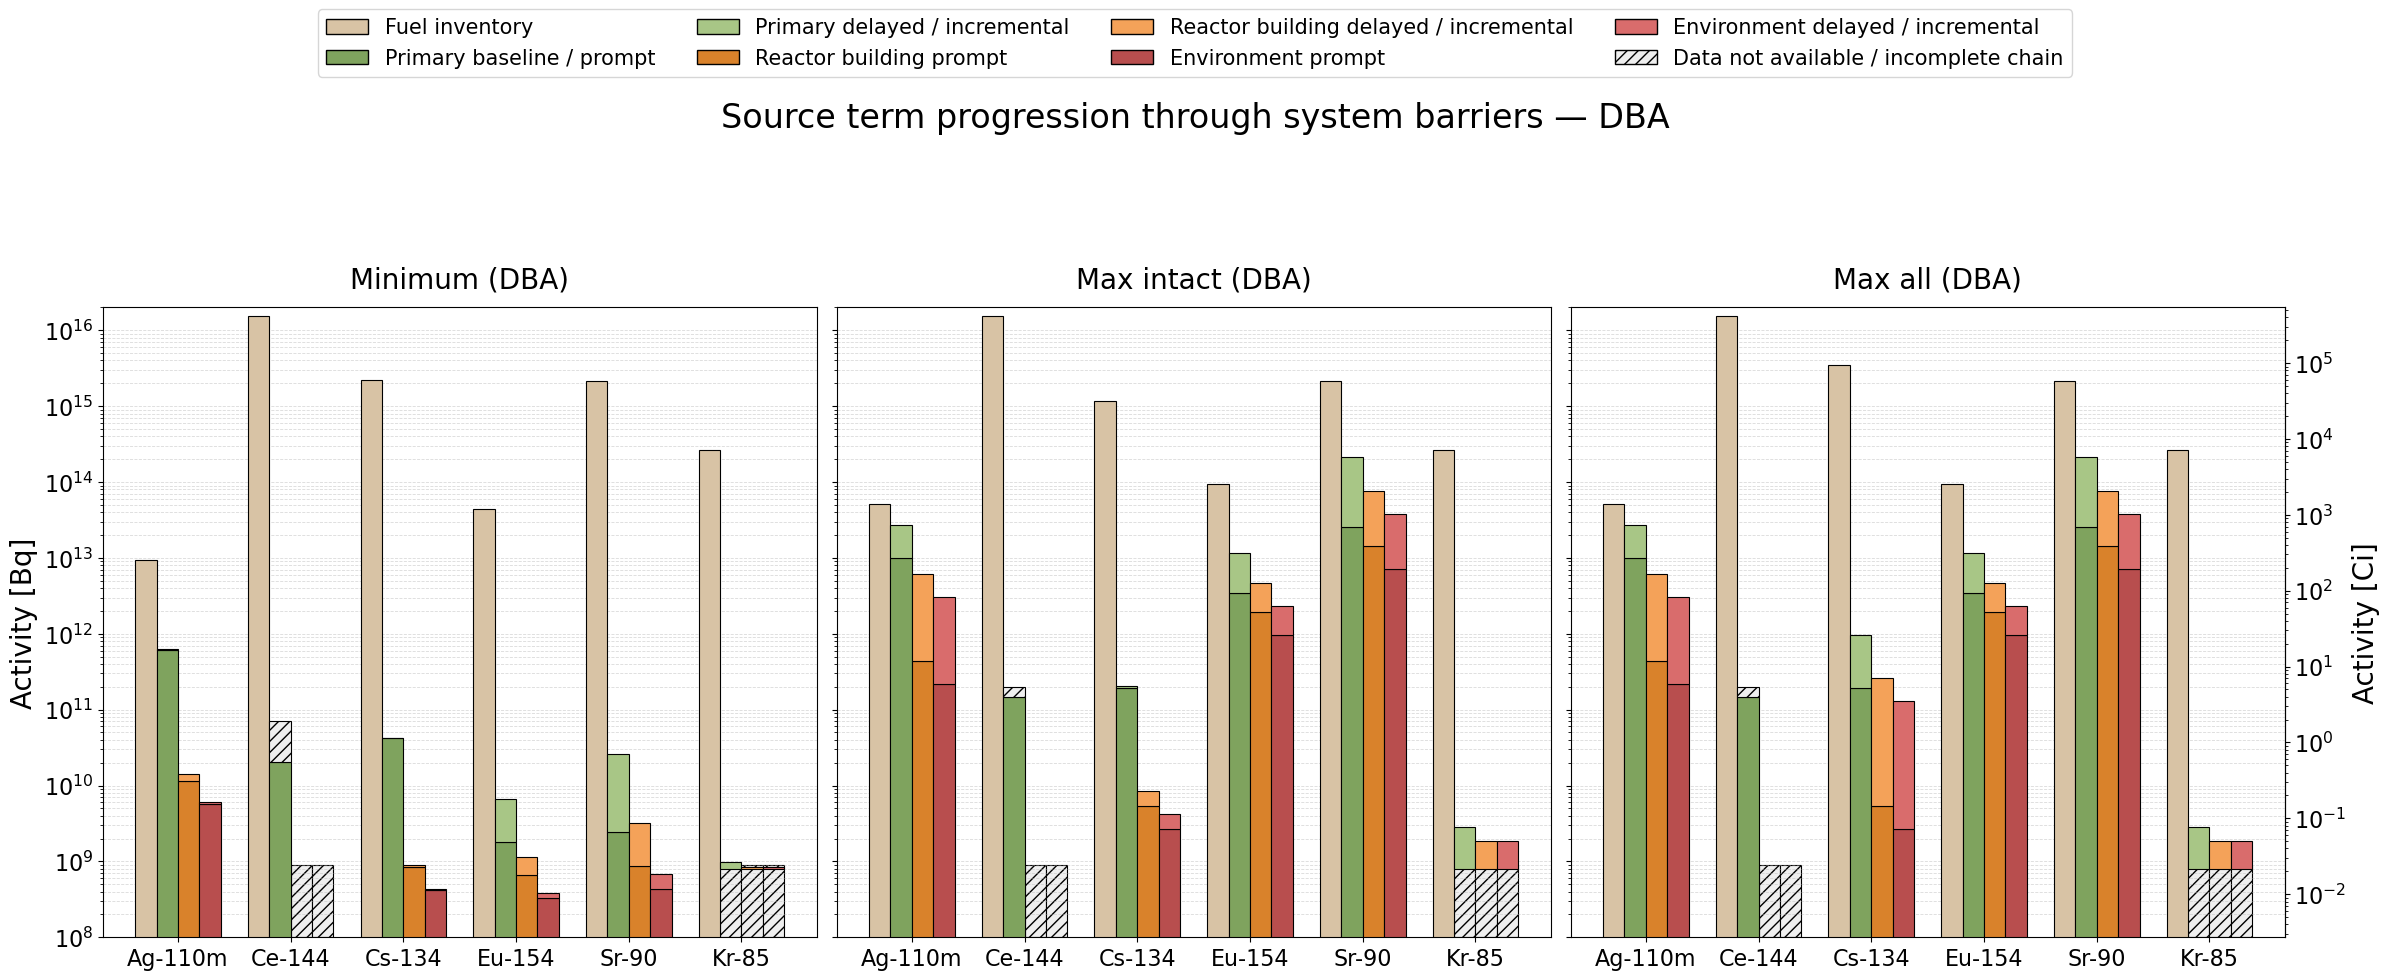

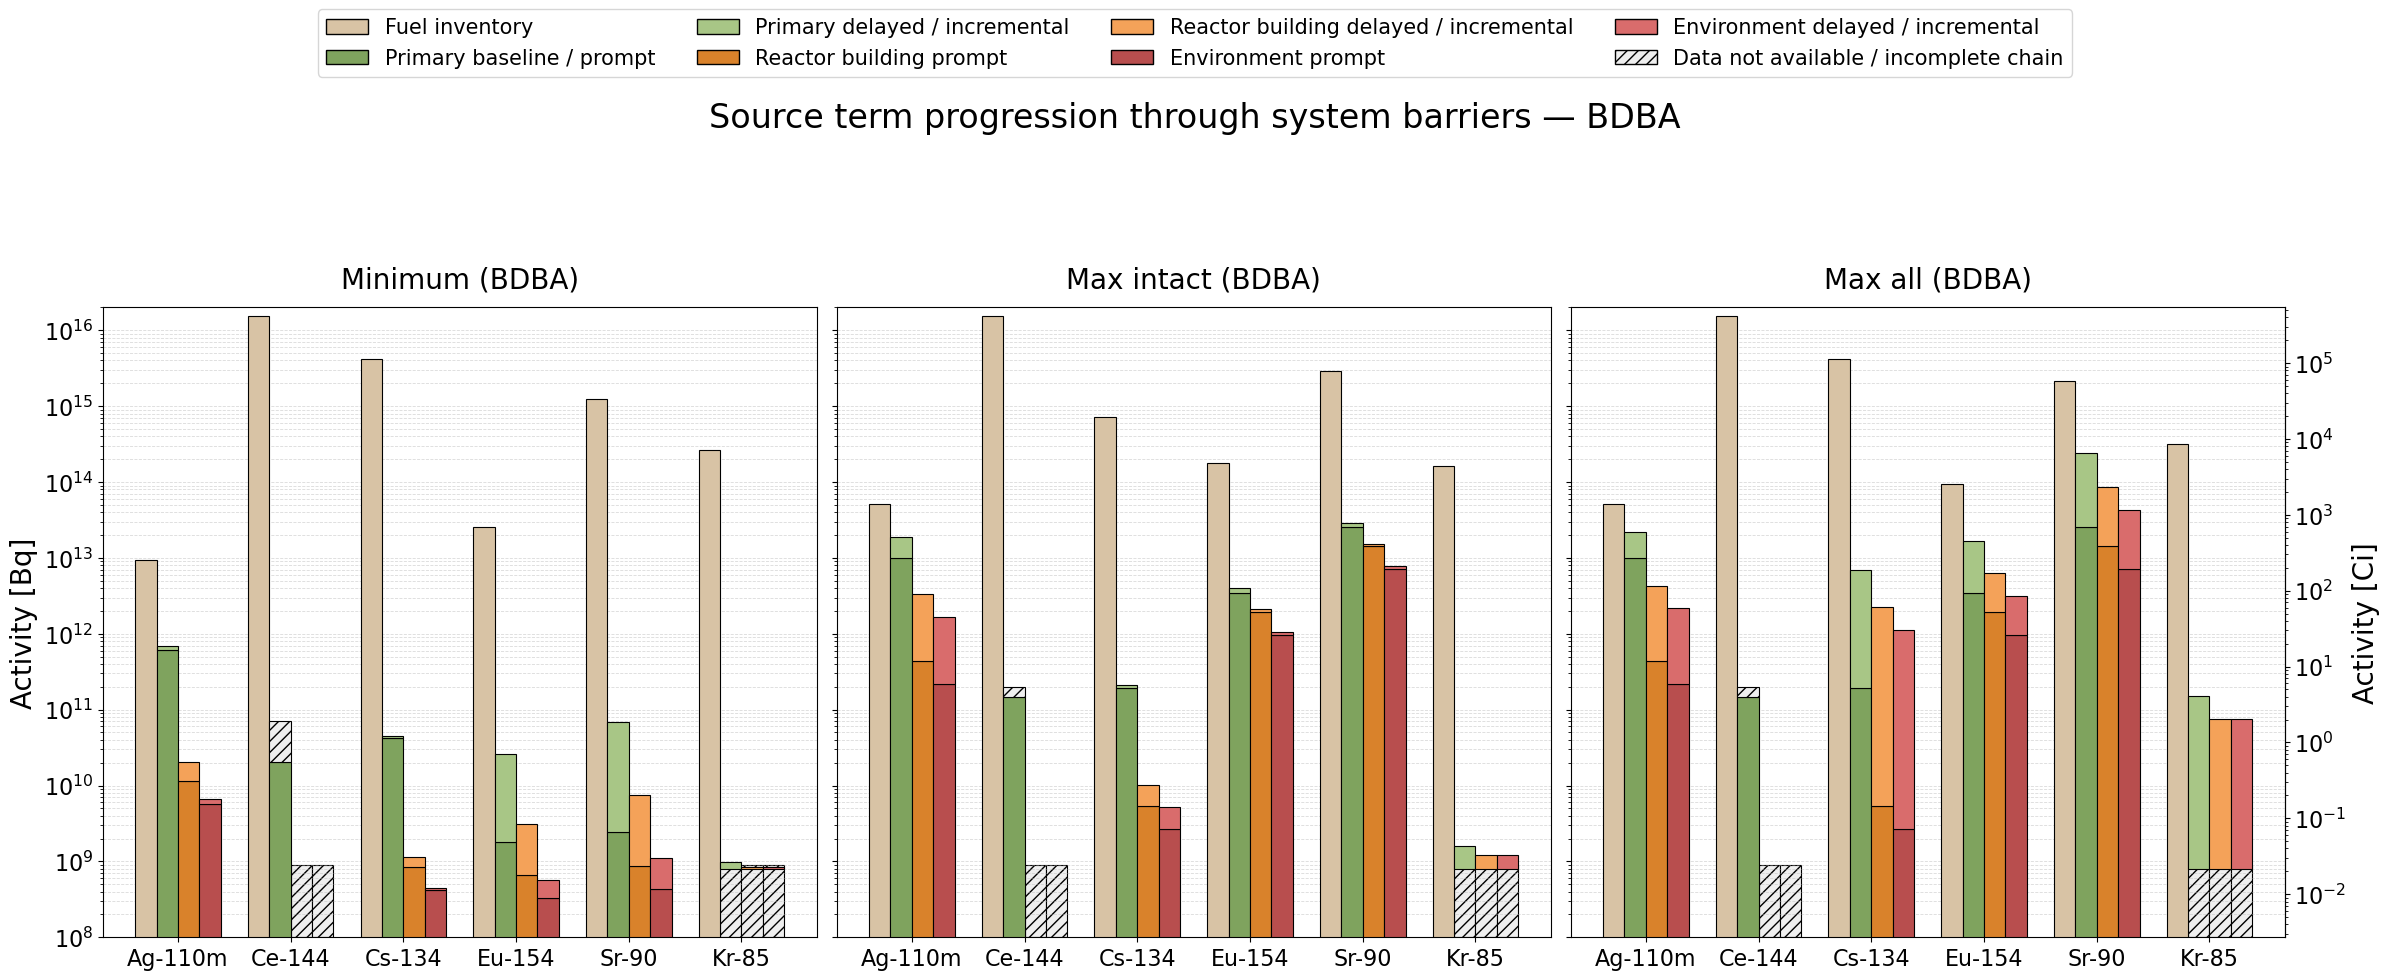

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogFormatterSciNotation

# ============================================================
# Improved large thesis-ready plots:
#   Figure 1: DBA, 1 x 3 panels
#   Figure 2: BDBA, 1 x 3 panels
# ============================================================

# --- Isotopes shown ---
isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]

label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}
labels = [label_map.get(iso, iso) for iso in isotopes]

# --- Helper function ---
def get_case_value(dct, iso, case, default=0.0):
    if iso in dct and case in dct[iso]:
        return dct[iso][case]
    return default

# --- Colors ---
color_fuel = "#D8C3A5"

color_primary_base = "#7FA35E"
color_primary_inc  = "#A8C686"

color_building_base = "#D9822B"
color_building_inc  = "#F4A259"

color_env_base = "#B84E4E"
color_env_inc  = "#D96C6C"

color_missing = "#EFEFEF"

# --- Font sizes for thesis/report readability ---
TITLE_SIZE = 20
LABEL_SIZE = 20
TICK_SIZE = 16
LEGEND_SIZE = 15
SUPTITLE_SIZE = 24

# --- Curie conversion ---
CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

# --- X-axis setup ---
x = np.arange(len(isotopes))
width = 0.19

# --- Axis limits / hatch heights ---
ymin = 1e8
ymax = 2e16
HATCH_H = 8e8
HATCH_H_INC = 5e10

# ============================================================
# NO / baseline data
# ============================================================
fuel_min_NO = np.array([
    get_case_value(fuel_inventory_RF_NO, iso, "min", {}).get("activity", 0.0)
    for iso in isotopes
])
fuel_max_NO = np.array([
    get_case_value(fuel_inventory_RF_NO, iso, "max", {}).get("activity", 0.0)
    for iso in isotopes
])

primary_min_NO = np.array([get_case_value(A_primary_NO, iso, "min") for iso in isotopes])
primary_max_NO = np.array([get_case_value(A_primary_NO, iso, "max") for iso in isotopes])

building_min_NO = np.array([get_case_value(A_building_prompt, iso, "min") for iso in isotopes])
building_max_NO = np.array([get_case_value(A_building_prompt, iso, "max") for iso in isotopes])

env_min_NO = np.array([get_case_value(A_environment_prompt, iso, "min") for iso in isotopes])
env_max_NO = np.array([get_case_value(A_environment_prompt, iso, "max") for iso in isotopes])

# ============================================================
# DBA incremental data
# ============================================================
fuel_min_DBA = np.array([
    get_case_value(fuel_inventory_RF_DBA, iso, "min", {}).get("activity", 0.0)
    for iso in isotopes
])
fuel_intact_DBA = np.array([
    get_case_value(fuel_inventory_RF_DBA, iso, "max_intact", {}).get("activity", 0.0)
    for iso in isotopes
])
fuel_all_DBA = np.array([
    get_case_value(fuel_inventory_RF_DBA, iso, "max_all", {}).get("activity", 0.0)
    for iso in isotopes
])

primary_min_DBA_inc = np.array([get_case_value(A_primary_DBA, iso, "min") for iso in isotopes])
primary_intact_DBA_inc = np.array([get_case_value(A_primary_DBA, iso, "max_intact") for iso in isotopes])
primary_all_DBA_inc = np.array([get_case_value(A_primary_DBA, iso, "max_all") for iso in isotopes])

building_min_DBA_inc = np.array([get_case_value(A_building_DBA_incremental, iso, "min") for iso in isotopes])
building_intact_DBA_inc = np.array([get_case_value(A_building_DBA_incremental, iso, "max_intact") for iso in isotopes])
building_all_DBA_inc = np.array([get_case_value(A_building_DBA_incremental, iso, "max_all") for iso in isotopes])

env_min_DBA_inc = np.array([get_case_value(A_environment_DBA_incremental, iso, "min") for iso in isotopes])
env_intact_DBA_inc = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_intact") for iso in isotopes])
env_all_DBA_inc = np.array([get_case_value(A_environment_DBA_incremental, iso, "max_all") for iso in isotopes])

# ============================================================
# BDBA incremental data
# ============================================================
fuel_min_BDBA = np.array([
    get_case_value(fuel_inventory_RF_BDBA, iso, "min", {}).get("activity", 0.0)
    for iso in isotopes
])
fuel_intact_BDBA = np.array([
    get_case_value(fuel_inventory_RF_BDBA, iso, "max_intact", {}).get("activity", 0.0)
    for iso in isotopes
])
fuel_all_BDBA = np.array([
    get_case_value(fuel_inventory_RF_BDBA, iso, "max_all", {}).get("activity", 0.0)
    for iso in isotopes
])

primary_min_BDBA_inc = np.array([get_case_value(A_primary_BDBA, iso, "min") for iso in isotopes])
primary_intact_BDBA_inc = np.array([get_case_value(A_primary_BDBA, iso, "max_intact") for iso in isotopes])
primary_all_BDBA_inc = np.array([get_case_value(A_primary_BDBA, iso, "max_all") for iso in isotopes])

building_min_BDBA_inc = np.array([get_case_value(A_building_BDBA_incremental, iso, "min") for iso in isotopes])
building_intact_BDBA_inc = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_intact") for iso in isotopes])
building_all_BDBA_inc = np.array([get_case_value(A_building_BDBA_incremental, iso, "max_all") for iso in isotopes])

env_min_BDBA_inc = np.array([get_case_value(A_environment_BDBA_incremental, iso, "min") for iso in isotopes])
env_intact_BDBA_inc = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_intact") for iso in isotopes])
env_all_BDBA_inc = np.array([get_case_value(A_environment_BDBA_incremental, iso, "max_all") for iso in isotopes])

# ============================================================
# Ce-144 from NO only
# ============================================================
ce_no = {
    "min": {
        "fuel": fuel_inventory_RF_NO["Ce144"]["min"]["activity"],
        "primary": A_primary_NO["Ce144"]["min"],
    },
    "intact": {
        "fuel": fuel_inventory_RF_NO["Ce144"]["max"]["activity"],
        "primary": A_primary_NO["Ce144"]["max"],
    },
    "all": {
        "fuel": fuel_inventory_RF_NO["Ce144"]["max"]["activity"],
        "primary": A_primary_NO["Ce144"]["max"],
    }
}

# ============================================================
# Drawing function for one panel
# ============================================================
def draw_panel(ax, fuel_vals, primary_base, primary_inc,
               building_base, building_inc,
               env_base, env_inc,
               title, case_key):

    ax.set_facecolor("white")

    xpos_fuel = x - 1.5 * width
    xpos_primary = x - 0.5 * width
    xpos_building = x + 0.5 * width
    xpos_env = x + 1.5 * width

    for i, iso in enumerate(isotopes):

        # -------------------------
        # Fuel inventory
        # -------------------------
        if iso == "Ce144":
            ax.bar(
                xpos_fuel[i], ce_no[case_key]["fuel"], width,
                color=color_fuel, edgecolor="black", linewidth=0.8, zorder=2
            )
        elif fuel_vals[i] > 0:
            ax.bar(
                xpos_fuel[i], fuel_vals[i], width,
                color=color_fuel, edgecolor="black", linewidth=0.8, zorder=2
            )
        else:
            ax.bar(
                xpos_fuel[i], HATCH_H, width, bottom=ymin,
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=1
            )

        # -------------------------
        # Primary system
        # -------------------------
        if iso == "Kr85":
            ax.bar(
                xpos_primary[i], HATCH_H, width, bottom=ymin,
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=1
            )
            ax.bar(
                xpos_primary[i], primary_inc[i], width, bottom=HATCH_H,
                color=color_primary_inc, edgecolor="black",
                linewidth=0.8, zorder=2
            )

        elif iso == "Ce144":
            ax.bar(
                xpos_primary[i], ce_no[case_key]["primary"], width,
                color=color_primary_base, edgecolor="black",
                linewidth=0.8, zorder=2
            )
            ax.bar(
                xpos_primary[i], HATCH_H_INC, width,
                bottom=ce_no[case_key]["primary"],
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=3
            )

        else:
            ax.bar(
                xpos_primary[i], primary_base[i], width,
                color=color_primary_base, edgecolor="black",
                linewidth=0.8, zorder=2
            )
            ax.bar(
                xpos_primary[i], primary_inc[i], width,
                bottom=primary_base[i],
                color=color_primary_inc, edgecolor="black",
                linewidth=0.8, zorder=3
            )

        # -------------------------
        # Reactor building
        # -------------------------
        if iso == "Ce144":
            ax.bar(
                xpos_building[i], HATCH_H, width, bottom=ymin,
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=1
            )

        elif iso == "Kr85":
            ax.bar(
                xpos_building[i], HATCH_H, width, bottom=ymin,
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=1
            )
            ax.bar(
                xpos_building[i], building_inc[i], width, bottom=HATCH_H,
                color=color_building_inc, edgecolor="black",
                linewidth=0.8, zorder=2
            )

        else:
            ax.bar(
                xpos_building[i], building_base[i], width,
                color=color_building_base, edgecolor="black",
                linewidth=0.8, zorder=2
            )
            ax.bar(
                xpos_building[i], building_inc[i], width,
                bottom=building_base[i],
                color=color_building_inc, edgecolor="black",
                linewidth=0.8, zorder=3
            )

        # -------------------------
        # Environment
        # -------------------------
        if iso == "Ce144":
            ax.bar(
                xpos_env[i], HATCH_H, width, bottom=ymin,
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=1
            )

        elif iso == "Kr85":
            ax.bar(
                xpos_env[i], HATCH_H, width, bottom=ymin,
                color=color_missing, edgecolor="black",
                linewidth=0.8, hatch="///", zorder=1
            )
            ax.bar(
                xpos_env[i], env_inc[i], width, bottom=HATCH_H,
                color=color_env_inc, edgecolor="black",
                linewidth=0.8, zorder=2
            )

        else:
            ax.bar(
                xpos_env[i], env_base[i], width,
                color=color_env_base, edgecolor="black",
                linewidth=0.8, zorder=2
            )
            ax.bar(
                xpos_env[i], env_inc[i], width,
                bottom=env_base[i],
                color=color_env_inc, edgecolor="black",
                linewidth=0.8, zorder=3
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=TICK_SIZE)
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=TITLE_SIZE, pad=14)

    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.tick_params(axis="both", which="minor", labelsize=TICK_SIZE - 2)

    ax.grid(
        axis="y",
        which="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.45
    )

# ============================================================
# Legend handles
# ============================================================
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_fuel, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_primary_base, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_primary_inc, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_building_base, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_building_inc, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_env_base, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_env_inc, ec="black"),
    plt.Rectangle((0, 0), 1, 1, color=color_missing, ec="black", hatch="///"),
]

labels_legend = [
    "Fuel inventory",
    "Primary baseline / prompt",
    "Primary delayed / incremental",
    "Reactor building prompt",
    "Reactor building delayed / incremental",
    "Environment prompt",
    "Environment delayed / incremental",
    "Data not available / incomplete chain"
]

# ============================================================
# Function for one full scenario figure
# ============================================================
def make_scenario_figure(
    scenario_name,
    fuel_min, fuel_intact, fuel_all,
    primary_min_inc, primary_intact_inc, primary_all_inc,
    building_min_inc, building_intact_inc, building_all_inc,
    env_min_inc, env_intact_inc, env_all_inc,
    save_name=None
):

    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 8.5),
        sharey=True,
        facecolor="white"
    )

    draw_panel(
        axes[0],
        fuel_min,
        primary_min_NO, primary_min_inc,
        building_min_NO, building_min_inc,
        env_min_NO, env_min_inc,
        f"Minimum ({scenario_name})",
        "min"
    )

    draw_panel(
        axes[1],
        fuel_intact,
        primary_max_NO, primary_intact_inc,
        building_max_NO, building_intact_inc,
        env_max_NO, env_intact_inc,
        f"Max intact ({scenario_name})",
        "intact"
    )

    draw_panel(
        axes[2],
        fuel_all,
        primary_max_NO, primary_all_inc,
        building_max_NO, building_all_inc,
        env_max_NO, env_all_inc,
        f"Max all ({scenario_name})",
        "all"
    )

    axes[0].set_ylabel("Activity [Bq]", fontsize=LABEL_SIZE)

    # Secondary right y-axis in Ci
    secax = axes[2].secondary_yaxis(
        "right",
        functions=(bq_to_ci, ci_to_bq)
    )
    secax.set_ylabel("Activity [Ci]", fontsize=LABEL_SIZE)
    secax.yaxis.set_major_formatter(LogFormatterSciNotation())
    secax.tick_params(axis="y", labelsize=TICK_SIZE)

    fig.suptitle(
        f"Source term progression through system barriers — {scenario_name}",
        fontsize=SUPTITLE_SIZE,
        y=1.04
    )

    fig.legend(
        handles,
        labels_legend,
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 1.16),
        frameon=True,
        fontsize=LEGEND_SIZE
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save_name is not None:
        fig.savefig(f"{save_name}.png", dpi=300, bbox_inches="tight")
        fig.savefig(f"{save_name}.pdf", bbox_inches="tight")

    plt.show()

# ============================================================
# Make DBA figure
# ============================================================
make_scenario_figure(
    "DBA",
    fuel_min_DBA, fuel_intact_DBA, fuel_all_DBA,
    primary_min_DBA_inc, primary_intact_DBA_inc, primary_all_DBA_inc,
    building_min_DBA_inc, building_intact_DBA_inc, building_all_DBA_inc,
    env_min_DBA_inc, env_intact_DBA_inc, env_all_DBA_inc,
    save_name="source_term_progression_DBA"
)

# ============================================================
# Make BDBA figure
# ============================================================
make_scenario_figure(
    "BDBA",
    fuel_min_BDBA, fuel_intact_BDBA, fuel_all_BDBA,
    primary_min_BDBA_inc, primary_intact_BDBA_inc, primary_all_BDBA_inc,
    building_min_BDBA_inc, building_intact_BDBA_inc, building_all_BDBA_inc,
    env_min_BDBA_inc, env_intact_BDBA_inc, env_all_BDBA_inc,
    save_name="source_term_progression_BDBA"
)

### Activity vs burnup

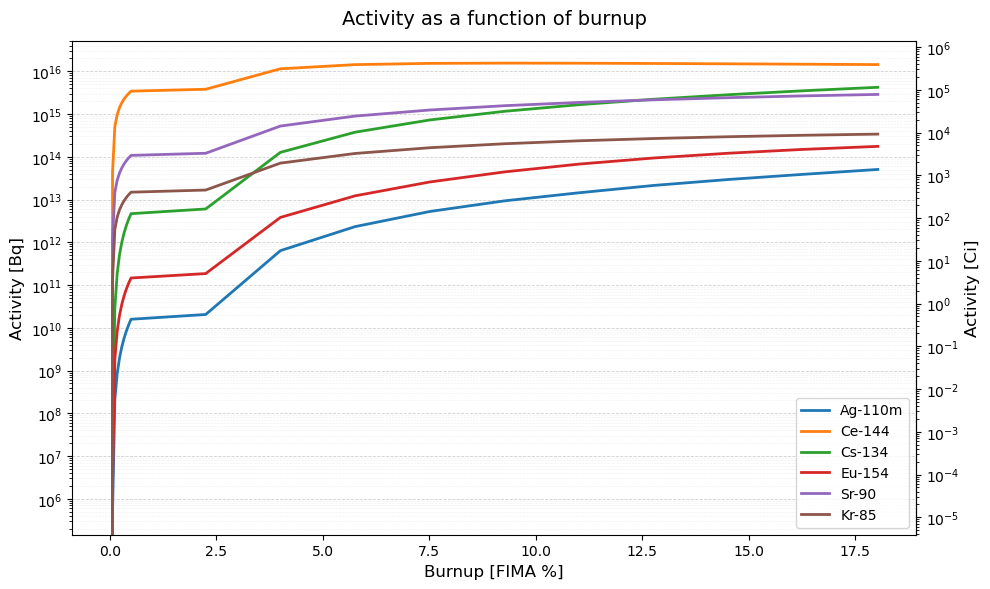

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import openmc
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

# --- Isotoper ---
nuclide_names = {
    "Ag110m": "Ag110_m1",
    "Ce144": "Ce144",
    "Cs134": "Cs134",
    "Eu154": "Eu154",
    "Sr90": "Sr90",
    "Kr85": "Kr85"
}

label_map = {
    "Ag110m": "Ag-110m",
    "Ce144": "Ce-144",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
    "Kr85": "Kr-85"
}

isotopes = ["Ag110m", "Ce144", "Cs134", "Eu154", "Sr90", "Kr85"]

# --- Hent aktivitet fra atoms ---
def get_atoms_array(results, material_id, nuc):
    _, atoms = results.get_atoms(material_id, nuc)
    return np.array(atoms, dtype=float)

def get_decay_constant(nuc):
    return openmc.data.decay_constant(nuc)

activity_data = {}

for iso in isotopes:
    nuc = nuclide_names[iso]
    try:
        atoms = get_atoms_array(results, material_id, nuc)
        lam = get_decay_constant(nuc)
        activity_data[iso] = lam * atoms
    except Exception as e:
        print(f"Could not load {iso}: {e}")

# --- Match lengde ---
for iso in activity_data:
    if len(activity_data[iso]) > len(FIMA_array):
        activity_data[iso] = activity_data[iso][:len(FIMA_array)]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

for iso in isotopes:
    if iso in activity_data:
        ax.plot(FIMA_array[:len(activity_data[iso])],
                activity_data[iso],
                label=label_map[iso],
                linewidth=2)

# --- Log y-akse ---
ax.set_yscale("log")

# --- Fine log ticks ---
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
ax.yaxis.set_major_formatter(LogFormatterSciNotation())
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)*0.1, numticks=100))

# --- Kun horisontal grid ---
ax.grid(axis="y", which="major", linestyle="--", linewidth=0.6, alpha=0.6)
ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.4, alpha=0.4)

# --- Labels ---
ax.set_xlabel("Burnup [FIMA %]", fontsize=12)
ax.set_ylabel("Activity [Bq]", fontsize=12)
ax.set_title("Activity as a function of burnup", fontsize=14, pad=12)

ax.legend(frameon=True)

# =========================
# Secondary axis (Ci)
# =========================
CI_PER_BQ = 1 / 3.7e10

def bq_to_ci(x):
    return x * CI_PER_BQ

def ci_to_bq(x):
    return x / CI_PER_BQ

secax = ax.secondary_yaxis('right', functions=(bq_to_ci, ci_to_bq))
secax.set_ylabel("Activity [Ci]", fontsize=12)

# Match log style (uten grid)
secax.set_yscale("log")
secax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
secax.yaxis.set_major_formatter(LogFormatterSciNotation())
secax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)*0.1, numticks=100))

plt.tight_layout()
plt.show()

### Final source term table

In [29]:
import pandas as pd

label_map = {
    "Ag110m": "Ag-110m",
    "Cs134": "Cs-134",
    "Eu154": "Eu-154",
    "Sr90": "Sr-90",
}

rows = []

for iso in isotopes_full:
    rows.append({
        "Isotope": label_map.get(iso, iso),
        "min [Bq]": A_environment_DBA_total[iso]["min"],
        "max intact [Bq]": A_environment_DBA_total[iso]["max_intact"],
        "max all [Bq]": A_environment_DBA_total[iso]["max_all"],
    })

df_DBA_source_term = pd.DataFrame(rows)

df_DBA_source_term

,Isotope,min [Bq],max intact [Bq],max all [Bq]
0,Ag-110m,6.044624e+09,3.092164e+12,3.092164e+12
1,Cs-134,4.266795e+08,4.200394e+09,1.313848e+11
2,Eu-154,3.777076e+08,2.352883e+12,2.352883e+12
3,Sr-90,6.737473e+08,3.816945e+13,3.816945e+13


In [30]:
print(df_DBA_source_term.to_latex(
    index=False,
    float_format="%.3e",
    caption="Final environmental source term for the DBA scenario.",
    label="tab:dba_environment_source_term"
))

\begin{table}
\caption{Final environmental source term for the DBA scenario.}
\label{tab:dba_environment_source_term}
\begin{tabular}{lrrr}
\toprule
Isotope & min [Bq] & max intact [Bq] & max all [Bq] \\
\midrule
Ag-110m & 6.045e+09 & 3.092e+12 & 3.092e+12 \\
Cs-134 & 4.267e+08 & 4.200e+09 & 1.314e+11 \\
Eu-154 & 3.777e+08 & 2.353e+12 & 2.353e+12 \\
Sr-90 & 6.737e+08 & 3.817e+13 & 3.817e+13 \\
\bottomrule
\end{tabular}
\end{table}



### Fuel inventory comparison with HTR-10

In [31]:
# =========================
# Fuel inventory at 1161 days for selected isotopes
# =========================

target_day = 1161.0
target_seconds = target_day * 86400.0

isotopes_check = ["Sr90", "Cs134", "Ag110_m1"]

# Hent tid fra én isotop (samme for alle)
times_s, _ = results.get_atoms(material_id, isotopes_check[0])
times_s = np.array(times_s, dtype=float)

# Finn nærmeste step
step = int(np.argmin(np.abs(times_s - target_seconds)))

matched_day = times_s[step] / 86400.0
matched_fima = FIMA_array[step]

print(f"Target time: {target_day:.1f} days")
print(f"Matched time: {matched_day:.2f} days")
print(f"Matched step: {step}")
print(f"Matched FIMA: {matched_fima:.4f}\n")

inventory_1161d = {}

for nuc in isotopes_check:
    A_array = get_activity_array(results, material_id, nuc)
    A_val = A_array[step]

    inventory_1161d[nuc] = A_val

    print(f"{nuc:8s}: {A_val:.3e} Bq")

Target time: 1161.0 days
Matched time: 1165.75 days
Matched step: 13
Matched FIMA: 7.5080

Sr90    : 1.246e+15 Bq
Cs134   : 7.288e+14 Bq
Ag110_m1: 5.266e+12 Bq
